# 02 - Data Understanding: Data Exploration
This notebook performs the data exploration and analysis phase of the pipeline. It loads the interim dataset from `data/external/` folder and perform all the essential steps of the EDA process.

## Import libraries and settings

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from pathlib import Path
from matplotlib.ticker import PercentFormatter
from yellowbrick.target import FeatureCorrelation
from yellowbrick.features import Rank1D

from fraud_dynamic_ensemble.config import EXTERNAL_DATA_DIR, FIGURES_DIR

2025-11-09 19:33:50.677 | INFO     | fraud_dynamic_ensemble.config:<module>:12 - PROJ_ROOT path is: /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Dynamic-Ensemble-Learning-for-Credit-Card-Fraud-Detection


In [2]:
input_path : Path = EXTERNAL_DATA_DIR / "creditcardfraud.csv"
print(f"Loading dataset at path:\n\t{input_path}")

Loading dataset at path:
	/home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Dynamic-Ensemble-Learning-for-Credit-Card-Fraud-Detection/data/external/creditcardfraud.csv


In [3]:
FIGURES_DATA_EXPLORATION_DIR = FIGURES_DIR / "DU_data_exploration"
FIGURES_DATA_EXPLORATION_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
pd.set_option('display.max_columns', None)
plt.rcParams.update({'font.size': 16})
sns.set_style("whitegrid")
sns.set_palette("tab10")

## Data Loading
We begin by loading the credit card fraud dataset. This is the untouched file downloaded from Kaggle. It contains anonymized PCA components (`V1`–`V28`), `Time`, `Amount`, and the `Class` label.

In [5]:
df = pd.read_csv(input_path, header=0, sep=",")
print(f"Dataset dimension\n"
      f"\t-Number of rows = {df.shape[0]}\n"
      f"\t-Number of cols = {df.shape[1]}")

Dataset dimension
	-Number of rows = 284807
	-Number of cols = 31


## Basic Overview

In [6]:
df.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,-0.371407,1.341262,0.359894,-0.358091,-0.137134,0.517617,0.401726,-0.058133,0.068653,-0.033194,0.084968,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,-0.099254,-1.416907,-0.153826,-0.751063,0.167372,0.050144,-0.443587,0.002821,-0.611987,-0.045575,-0.219633,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,1.249376,-0.619468,0.291474,1.757964,-1.323865,0.686133,-0.076127,-1.222127,-0.358222,0.324505,-0.156742,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,-0.410430,-0.705117,-0.110452,-0.286254,0.074355,-0.328783,-0.210077,-0.499768,0.118765,0.570328,0.052736,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,-0.366846,1.017614,0.836390,1.006844,-0.443523,0.150219,0.739453,-0.540980,0.476677,0.451773,0.203711,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


In [7]:
df.tail(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284797,172782.0,-0.241923,0.712247,0.399806,-0.463406,0.244531,-1.343668,0.929369,-0.206210,0.106234,-0.284708,-0.612982,-0.066655,-0.732987,0.237948,-0.293959,-0.245496,-0.174846,-0.891169,-0.290491,-0.139512,-0.228876,-0.514376,0.279598,0.371441,-0.559238,0.113144,0.131507,0.081265,5.49,0
284798,172782.0,0.219529,0.881246,-0.635891,0.960928,-0.152971,-1.014307,0.427126,0.121340,-0.285670,-0.111640,-1.109232,-0.453235,-1.046946,1.122674,1.243518,-1.431897,0.939328,-0.002373,2.894952,0.006666,0.099936,0.337120,0.251791,0.057688,-1.508368,0.144023,0.181205,0.215243,24.05,0
284799,172783.0,-1.775135,-0.004235,1.189786,0.331096,1.196063,5.519980,-1.518185,2.080825,1.159498,-0.594242,-1.264072,0.453596,-0.243142,-0.858719,-0.766554,-0.644646,0.447184,0.388721,0.792135,0.348176,0.103302,0.654850,-0.348929,0.745323,0.704545,-0.127579,0.454379,0.130308,79.99,0
284800,172784.0,2.039560,-0.175233,-1.196825,0.234580,-0.008713,-0.726571,0.017050,-0.118228,0.435402,0.267772,0.523316,0.559047,-0.834660,0.626211,-0.541494,0.225361,-0.605252,-0.163049,0.561695,-0.256922,-0.268048,-0.717211,0.297930,-0.359769,-0.315610,0.201114,-0.080826,-0.075071,2.68,0
284801,172785.0,0.120316,0.931005,-0.546012,-0.745097,1.130314,-0.235973,0.812722,0.115093,-0.204064,-0.657422,0.644837,0.190916,-0.546329,-0.731707,-0.808036,0.599628,0.070441,0.373110,0.128904,0.000676,-0.314205,-0.808520,0.050343,0.102800,-0.435870,0.124079,0.217940,0.068803,2.69,0
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,-1.593105,2.711941,-0.689256,4.626942,-0.924459,1.107641,1.991691,0.510632,-0.682920,1.475829,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,-0.150189,0.915802,1.214756,-0.675143,1.164931,-0.711757,-0.025693,-1.221179,-1.545556,0.059616,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,0.411614,0.063119,-0.183699,-0.510602,1.329284,0.140716,0.313502,0.395652,-0.577252,0.001396,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,-1.933849,-0.962886,-1.042082,0.449624,1.962563,-0.608577,0.509928,1.113981,2.897849,0.127434,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,-0.915427,-1.040458,-0.031513,-0.188093,-0.084316,0.041333,-0.302620,-0.660377,0.167430,-0.256117,0.382948,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [9]:
df['Class'] = df['Class'].astype('category')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype   
---  ------  --------------   -----   
 0   Time    284807 non-null  float64 
 1   V1      284807 non-null  float64 
 2   V2      284807 non-null  float64 
 3   V3      284807 non-null  float64 
 4   V4      284807 non-null  float64 
 5   V5      284807 non-null  float64 
 6   V6      284807 non-null  float64 
 7   V7      284807 non-null  float64 
 8   V8      284807 non-null  float64 
 9   V9      284807 non-null  float64 
 10  V10     284807 non-null  float64 
 11  V11     284807 non-null  float64 
 12  V12     284807 non-null  float64 
 13  V13     284807 non-null  float64 
 14  V14     284807 non-null  float64 
 15  V15     284807 non-null  float64 
 16  V16     284807 non-null  float64 
 17  V17     284807 non-null  float64 
 18  V18     284807 non-null  float64 
 19  V19     284807 non-null  float64 
 20  V20     284807 non-null  f

In [11]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,2.239053e-15,1.673327e-15,-1.247012e-15,8.190001e-16,1.207294e-15,4.887456e-15,1.437716e-15,-3.772171e-16,9.564149e-16,1.039917e-15,6.406204e-16,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,1.088850e+00,1.020713e+00,9.992014e-01,9.952742e-01,9.585956e-01,9.153160e-01,8.762529e-01,8.493371e-01,8.381762e-01,8.140405e-01,7.709250e-01,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,-2.458826e+01,-4.797473e+00,-1.868371e+01,-5.791881e+00,-1.921433e+01,-4.498945e+00,-1.412985e+01,-2.516280e+01,-9.498746e+00,-7.213527e+00,-5.449772e+01,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,-5.354257e-01,-7.624942e-01,-4.055715e-01,-6.485393e-01,-4.255740e-01,-5.828843e-01,-4.680368e-01,-4.837483e-01,-4.988498e-01,-4.562989e-01,-2.117214e-01,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,-9.291738e-02,-3.275735e-02,1.400326e-01,-1.356806e-02,5.060132e-02,4.807155e-02,6.641332e-02,-6.567575e-02,-3.636312e-03,3.734823e-03,-6.248109e-02,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,4.539234e-01,7.395934e-01,6.182380e-01,6.625050e-01,4.931498e-01,6.488208e-01,5.232963e-01,3.996750e-01,5.008067e-01,4.589494e-01,1.330408e-01,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,2.374514e+01,1.201891e+01,7.848392e+00,7.126883e+00,1.052677e+01,8.877742e+00,1.731511e+01,9.253526e+00,5.041069e+00,5.591971e+00,3.942090e+01,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000


## Class Balance
Visualize the class imbalance — essential for fraud detection tasks where Class 1 (fraud) is rare.

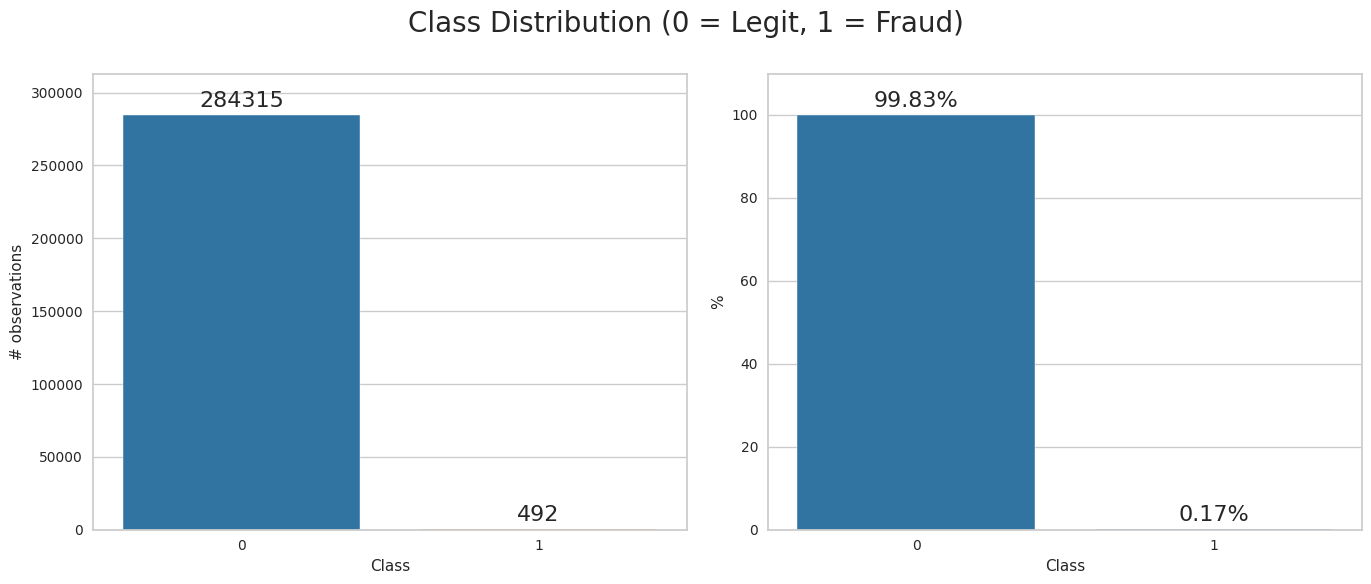

In [12]:
class_counts = df['Class'].value_counts().sort_index()
total = class_counts.sum()
class_percentages = class_counts / total * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1: Counting the observations per class
sns.countplot(ax=axes[0], data=df, x='Class', hue='Class', legend=False)
axes[0].set_xlabel("Class")
axes[0].set_ylabel("# observations")

for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.0f", padding=3)

axes[0].margins(y=0.1) # Avoid clipping labels at the top

# Subplot 2: Percentage per class
sns.barplot(ax=axes[1], x=class_percentages.index.astype(str), y=class_percentages.values)
axes[1].set_xlabel("Class")
axes[1].set_ylabel("%")

for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.2f%%", padding=3)

axes[1].margins(y=0.1)

plt.suptitle("Class Distribution (0 = Legit, 1 = Fraud)", fontsize=20)
plt.tight_layout()
plt.savefig(FIGURES_DATA_EXPLORATION_DIR / "class_distribution_absolute_vs_percentage.png", dpi=300)
plt.show()

##  Temporal Behavior Based on Relative Time

In [13]:
df['Time'].describe()

count    284807.000000
mean      94813.859575
std       47488.145955
min           0.000000
25%       54201.500000
50%       84692.000000
75%      139320.500000
max      172792.000000
Name: Time, dtype: float64

In [14]:
df['Time'].skew()

np.float64(-0.0355676180063216)

The **skewness value of approximately -0.036** is very close to zero. This indicates that the distribution of the `Time` feature is highly symmetrical.

The **mean (94,813.86)** is slightly greater than the **median (84,692.00)**. This small difference confirms the slight negative skew (mean should be less than the median for negative skew) and indicates that the data has a slightly heavier tail on the positive (right) side than on the negative (left) side, despite the skewness value being negative. The magnitude of the skewness is so small that a slight difference in mean/median is not significant.

The time values range from 0.00 to 172,792.00. The middle 50% of the data spans from 54,201.50 (25%) to 139,320.50 (75%).

The **standard deviation (47,488.14)** is relatively large compared to the mean, but the symmetrical nature suggests the spread is consistent with a normal-like distribution, and the min/max values appear reasonable for the overall range.

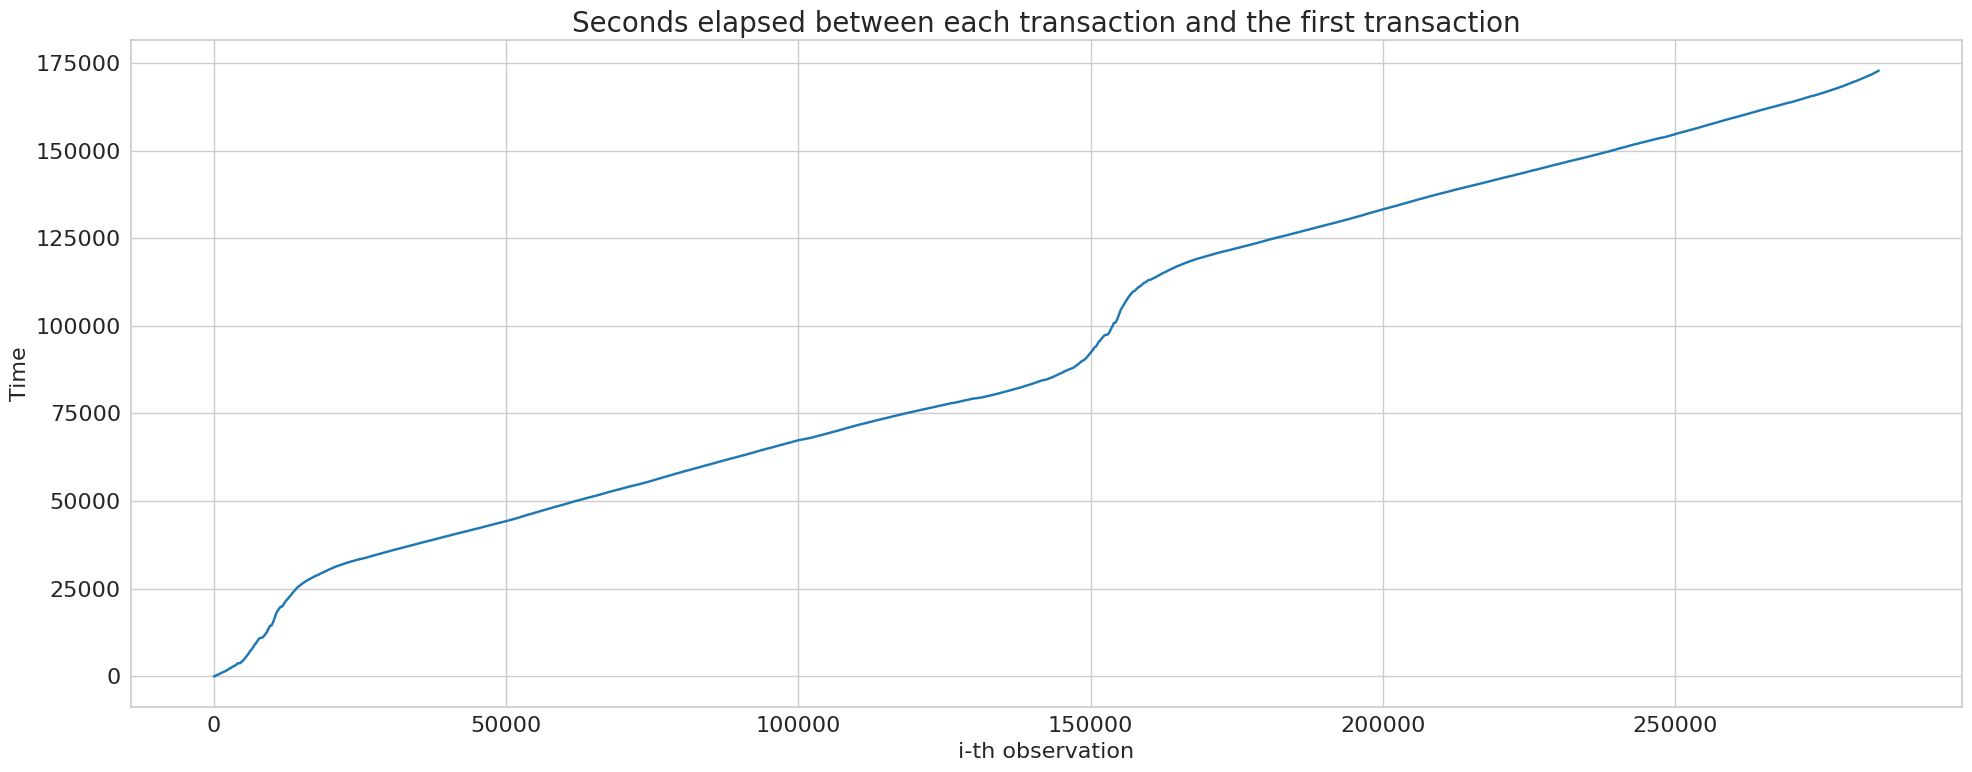

In [15]:
plt.figure(figsize=(20, 8))
df['Time'].plot()
plt.xlabel('i-th observation', fontsize=16)
plt.ylabel('Time', fontsize=16)
plt.tick_params(labelsize=16)
plt.title('Seconds elapsed between each transaction and the first transaction', fontsize=20)
plt.tight_layout()
plt.savefig(FIGURES_DATA_EXPLORATION_DIR / "time_seconds_elapsed_per_transactions.png", dpi=300)
plt.show()

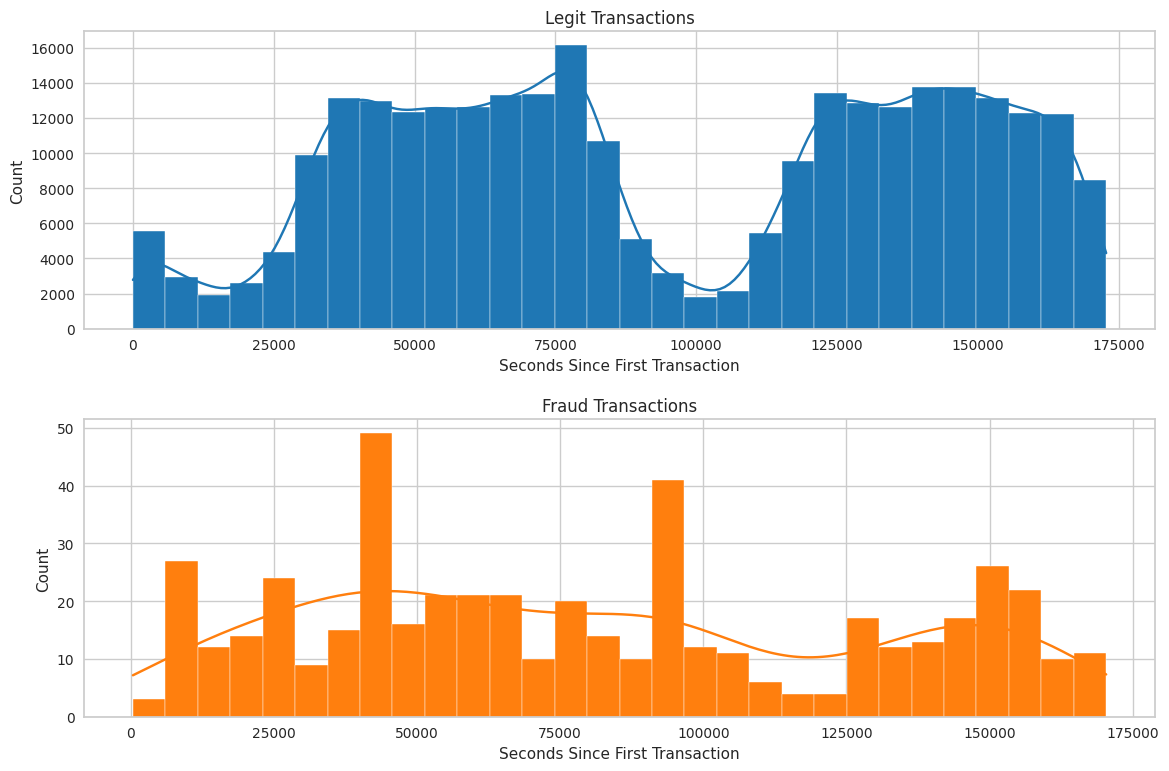

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Legit count distribution by hour
sns.histplot(df[df['Class'] == 0]['Time'],
             bins=30,
             stat="count",
             kde=True,
             color=sns.color_palette()[0],
             alpha=1.0,
             ax=axes[0])
axes[0].set_title("Legit Transactions")
axes[0].set_xlabel("Seconds Since First Transaction")

# Fraud counts distribution by hour
sns.histplot(df[df['Class'] == 1]['Time'],
             bins=30,
             stat="count",
             kde=True,
             color=sns.color_palette()[1],
             alpha=1.0,
             ax=axes[1])
axes[1].set_title("Fraud Transactions")
axes[1].set_xlabel("Seconds Since First Transaction")

plt.tight_layout()
plt.savefig(FIGURES_DATA_EXPLORATION_DIR / "time_distribution_by_seconds.png", dpi=300)
plt.show()

For Legit transactions, we can observe a repetitive wave pattern with two large peaks. This suggests transaction volume follows a diurnal (daily) cycle: possibly office hours and nighttime dips, repeated over two days. This gives us confidence that time reflects real-world temporal behavior.

For Fraud transactions, we have much lower volume, but the key insight is that fraud attempts are not uniformly distributed. We can see clusters/spikes in specific time windows. This suggests frauds may be targeted in bursts, likely by bots or coordinated attacks.

In [17]:
SECONDS_IN_DAY = 86400 # 60 x 60 x 24

# Step 1: Calculate the time of day in seconds
df['Time_day_seconds'] = df['Time'] % SECONDS_IN_DAY

df['Time_day_seconds'].describe()


count    284807.000000
mean      52336.622709
std       21049.420490
min           0.000000
25%       38153.500000
50%       54039.000000
75%       69587.000000
max       86398.000000
Name: Time_day_seconds, dtype: float64

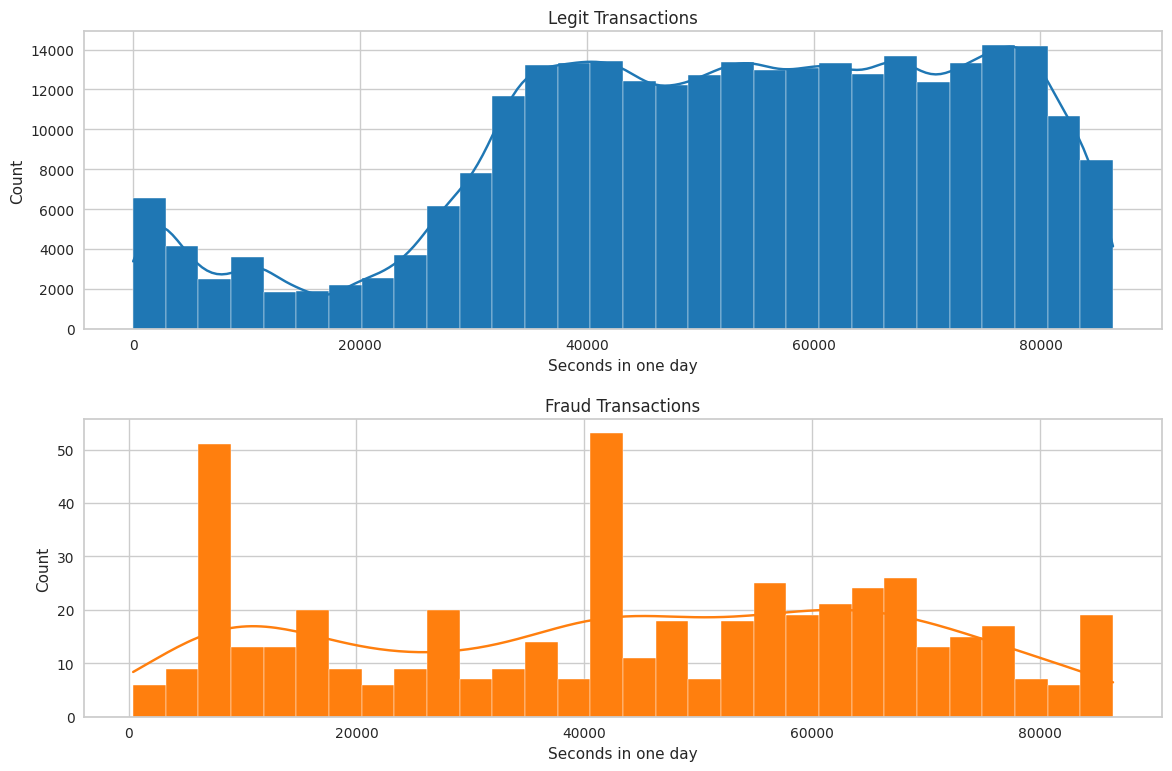

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Legit count distribution by hour
sns.histplot(df[df['Class'] == 0]['Time_day_seconds'],
             bins=30,
             stat="count",
             kde=True,
             color=sns.color_palette()[0],
             alpha=1.0,
             ax=axes[0])
axes[0].set_title("Legit Transactions")
axes[0].set_xlabel("Seconds in one day")

# Fraud counts distribution by hour
sns.histplot(df[df['Class'] == 1]['Time_day_seconds'],
             bins=30,
             stat="count",
             kde=True,
             color=sns.color_palette()[1],
             alpha=1.0,
             ax=axes[1])
axes[1].set_title("Fraud Transactions")
axes[1].set_xlabel("Seconds in one day")

plt.tight_layout()
plt.savefig(FIGURES_DATA_EXPLORATION_DIR / "time_distribution_by_seconds_in_one_dayy.png", dpi=300)
plt.show()

## Transaction Amount Distribution

In [19]:
# Understand the range, mean, standard deviation, presence of outliers and skewness.
df['Amount'].describe()

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

In [20]:
df['Amount'].skew()

np.float64(16.977724453761024)

The distribution of `Amount` is highly **skewed right (approximately 16.98)** . This means the vast majority of the transactions have very small amounts, and the long, thin tail of the distribution extends far out to the right due to a small number of extremely large transactions. These large transactions are acting as significant outliers.

The **mean (88.47)** is far greater than the **median (22.00)**. The mean is being pulled significantly upwards by the extremely large values in the right tail, while the median remains a robust measure of the typical transaction amount


The **standard deviation (250.4)** is extremely large compared to the mean. This indicates a **long right tail**, which is a common indicator of a highly skewed distribution and the presence of extreme outliers.

Presence of outliers: the maximum (25691.16) is hundreds of times larger than the median.

**Most transactions are small**:
- 75% of transactions are ≤ 77.51.
- So, 75% of transactions are under 80, and half are ≤ 22.

**There are zero-amount transactions**. This may:
- Represent failed/incomplete attempts.
- Be edge cases or errors.
- Indicate fraud tests (e.g., verifying a card).

In [21]:
df.groupby("Class", observed=True)["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


In [22]:
df.groupby("Class", observed=True)["Amount"].skew()

Class
0    17.003147
1     3.754477
Name: Amount, dtype: float64

**Class 0 - Legit** shows **extreme positive right skew (approximately 17)**, meaning that the vast majority of these transactions are small (median is 22.00), but a handful of transactions are extremely large (max is 25,691.16), pulling the mean (88.29) far away from the median.

**Class 1 - Fraud** shows **high positive right skew (approximately 3.75)**, meaning that the typical transaction in this group is very small (median is 9.25), even lower than the majority class. However, this class also has outliers, with a maximum amount of 2,125.87, which severely pulls the mean up to 122.21.


**Fraud Transactions** Tend to Have Lower Central Tendency:
- Median for fraud: 9.82
- Median for legit: 22.00

It suggests that many fraudulent transactions are small test payments — a typical pattern in fraud: attackers test cards with small charges.

Higher 75th Percentile for Fraud:
- 75% of frauds are below 105.89, while 75% of legits are below 77.46.
- The upper tail of frauds is heavier — indicating some high-value frauds, even though many are small.

More Variation in Fraud:
- Both classes have similar std dev (~250–260), but:
- Fraud has a much lower max: 2125.87 vs. 25691.16
- Legit class includes massive outliers
- Suggests fraud detection should not rely on raw Amount magnitude alone — log transform helps here.

In [23]:
for cls in [0, 1]:
    print(f"\nClass {cls} quantiles:")
    print(df[df.Class == cls]['Amount'].quantile([0.01, 0.25, 0.5, 0.75, 0.99, 0.999]))


Class 0 quantiles:
0.010       0.1200
0.250       5.6500
0.500      22.0000
0.750      77.0500
0.990    1016.9664
0.999    3000.0000
Name: Amount, dtype: float64

Class 1 quantiles:
0.010       0.00000
0.250       1.00000
0.500       9.25000
0.750     105.89000
0.990    1357.42790
0.999    1970.62071
Name: Amount, dtype: float64


**Lower Quantiles: Fraud is Smaller**

Fraud transactions at 1%, 25%, and 50% levels are significantly smaller than legitimate ones:
- Median fraud = 9.82, vs 22.00 for legit.
- 25% of frauds are ≤ $1.00 → suggests test charges or micro-transactions.

This aligns with prior findings: many frauds are low-value attempts

**Upper Quantiles: Fraud is More Concentrated**

At the 75th percentile:
- Fraud = 105.89
- Legit = 77.46

At the 99th percentile:

- Fraud = 1364
- Legit = 1018

But at the 99.9th percentile:
- Fraud tops out lower (1976) compared to legit (3012)

Fraud range is narrower, especially in upper outliers — legitimate users sometimes spend thousands; fraudsters rarely exceed 2000.

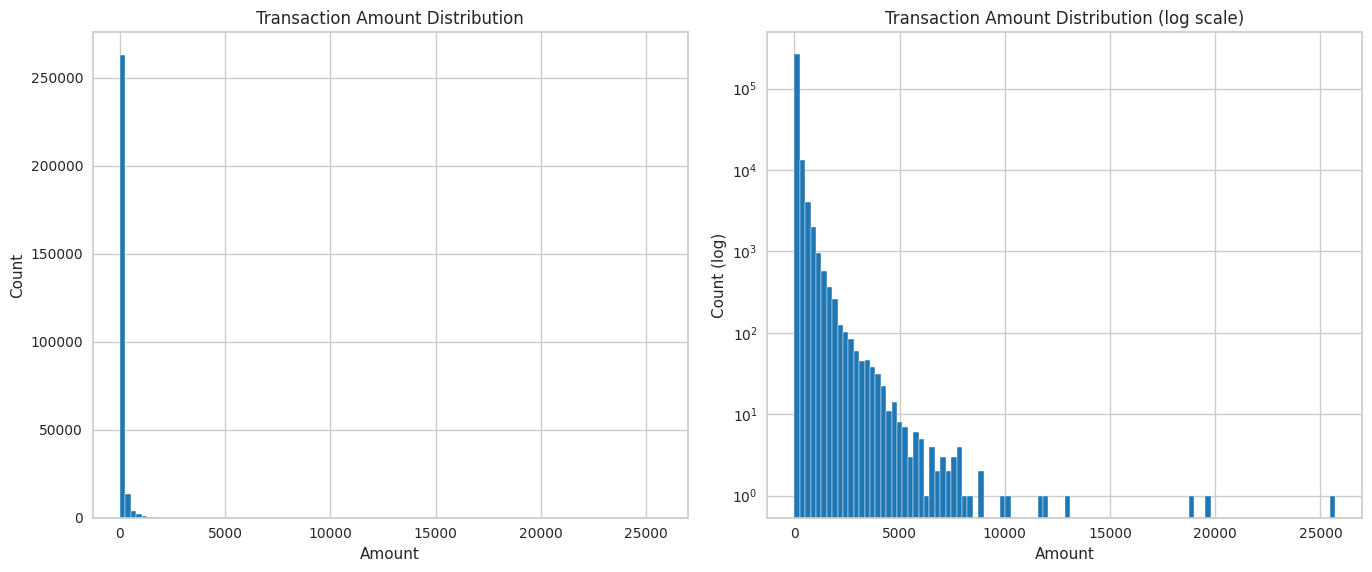

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.histplot(df['Amount'],
             bins=100,
             stat="count",
             kde=False,
             color=sns.color_palette()[0],
             alpha=1.0,
             fill=True,
             ax=axes[0])
axes[0].set_title("Transaction Amount Distribution")

sns.histplot(df['Amount'],
             bins=100,
             stat="count",
             kde=False,
             color=sns.color_palette()[0],
             alpha=1.0,
             ax=axes[1])
axes[1].set_title("Transaction Amount Distribution (log scale)")
axes[1].set_yscale('log')
axes[1].set_ylabel('Count (log)')

plt.tight_layout()
plt.savefig(FIGURES_DATA_EXPLORATION_DIR / "amount_distribution_log_scale.png", dpi=300)
plt.show()

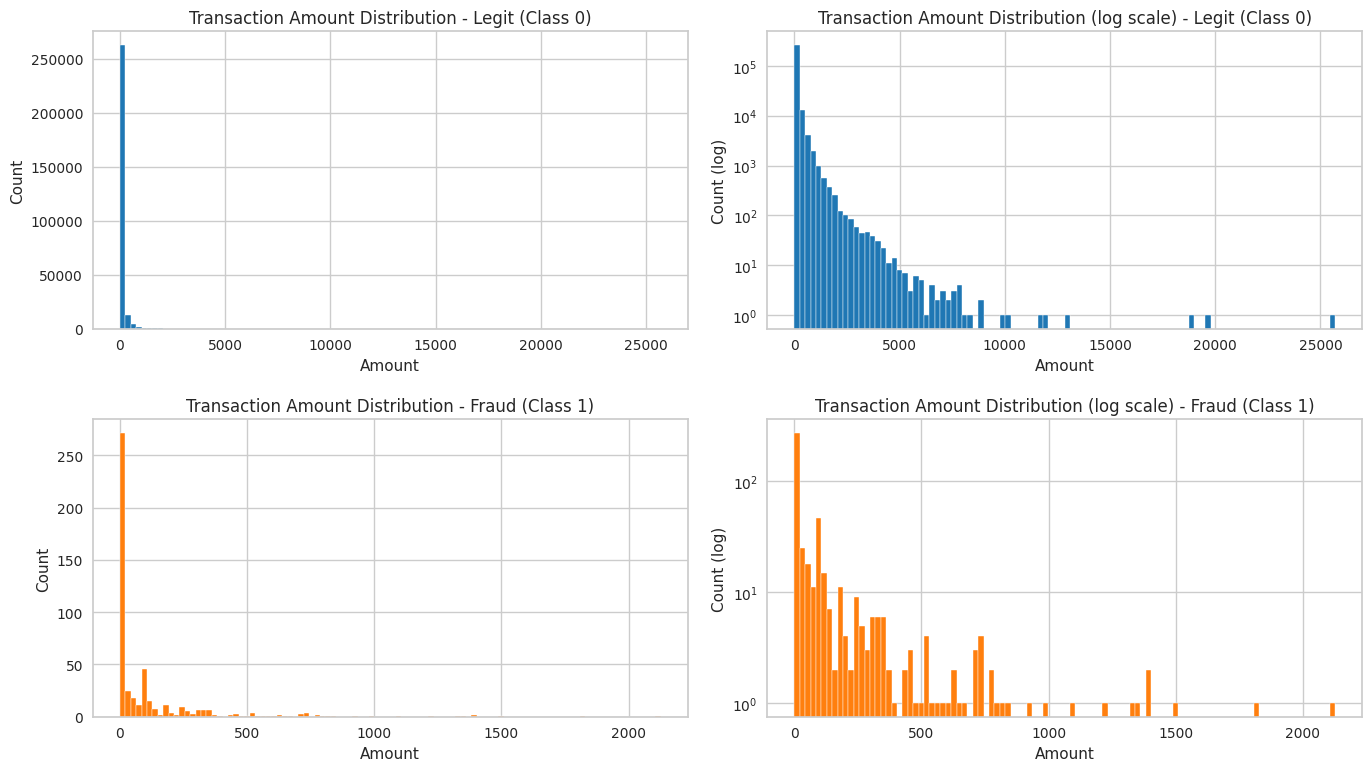

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

sns.histplot(df[df['Class'] == 0]['Amount'],
             bins=100,
             stat="count",
             kde=False,
             color=sns.color_palette()[0],
             alpha=1.0,
             fill=True,
             ax=axes[0,0])
axes[0,0].set_title("Transaction Amount Distribution - Legit (Class 0)")

sns.histplot(df[df['Class'] == 0]['Amount'],
             bins=100,
             stat="count",
             kde=False,
             color=sns.color_palette()[0],
             alpha=1.0,
             ax=axes[0,1])
axes[0,1].set_yscale('log')
axes[0,1].set_ylabel('Count (log)')
axes[0,1].set_title("Transaction Amount Distribution (log scale) - Legit (Class 0)")

sns.histplot(df[df['Class'] == 1]['Amount'],
             bins=100,
             stat="count",
             kde=False,
             color=sns.color_palette()[1],
             alpha=1.0,
             ax=axes[1,0])
axes[1,0].set_title("Transaction Amount Distribution - Fraud (Class 1)")

sns.histplot(df[df['Class'] == 1]['Amount'],
             bins=100,
             stat="count",
             kde=False,
             color=sns.color_palette()[1],
             alpha=1.0,
             ax=axes[1,1])
axes[1,1].set_yscale('log')
axes[1,1].set_ylabel('Count (log)')
axes[1,1].set_title("Transaction Amount Distribution (log scale) - Fraud (Class 1)")

plt.tight_layout()
plt.savefig(FIGURES_DATA_EXPLORATION_DIR / "amount_distribution_log_scale_by_class.png", dpi=300)
plt.show()

For any statistical analysis or machine learning model that assumes a normal distribution (like linear regression or many distance-based algorithms), this level of skewness will cause problems.

We will almost certainly need to apply a data transformation to reduce this skewness before modeling. Common transformations for such positive skew include:
- Logarithmic Transformation ($\log(x)$ or $\log(x+1)$ if zero values exist).
- Square Root Transformation ($\sqrt{x}$).
- Box-Cox Transformation.


Since there are **zero-amount transactions** which may represent failed/incomplete attempts, edge cases or errors, fraud tests (e.g., verifying a card), we select the **Logarithmic Transformation $\log(x+1)$**.


In [26]:
df['LogAmount'] = np.log1p(df['Amount'])

In [27]:
df['LogAmount'].describe()

count    284807.000000
mean          3.152188
std           1.656648
min           0.000000
25%           1.887070
50%           3.135494
75%           4.358822
max          10.153941
Name: LogAmount, dtype: float64

In [28]:
df['LogAmount'].skew()

np.float64(0.1627029277416401)

In [29]:
df.groupby("Class", observed=True)["LogAmount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,3.152762,1.655468,0.0,1.894617,3.135494,4.35735,10.153941
1,492.0,2.820596,2.214342,0.0,0.693147,2.327270,4.67180,7.662407


In [30]:
df.groupby("Class", observed=True)["LogAmount"].skew()

Class
0    0.162871
1    0.314055
Name: LogAmount, dtype: float64

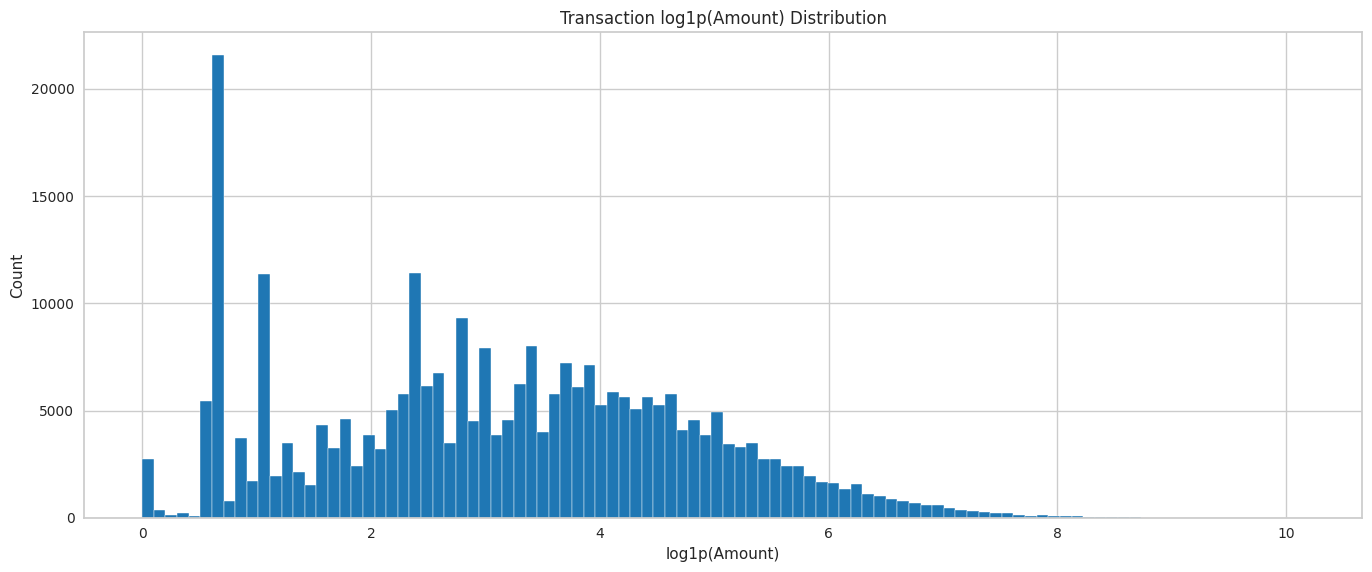

In [31]:
plt.figure(figsize=(14, 6))
sns.histplot(df['LogAmount'],
             bins=100,
             stat="count",
             kde=False,
             color=sns.color_palette()[0],
             alpha=1.0)

plt.xlabel("log1p(Amount)")
plt.title("Transaction log1p(Amount) Distribution")

plt.tight_layout()
plt.savefig(FIGURES_DATA_EXPLORATION_DIR / "amount_log1p_distribution.png", dpi=300)
plt.show()

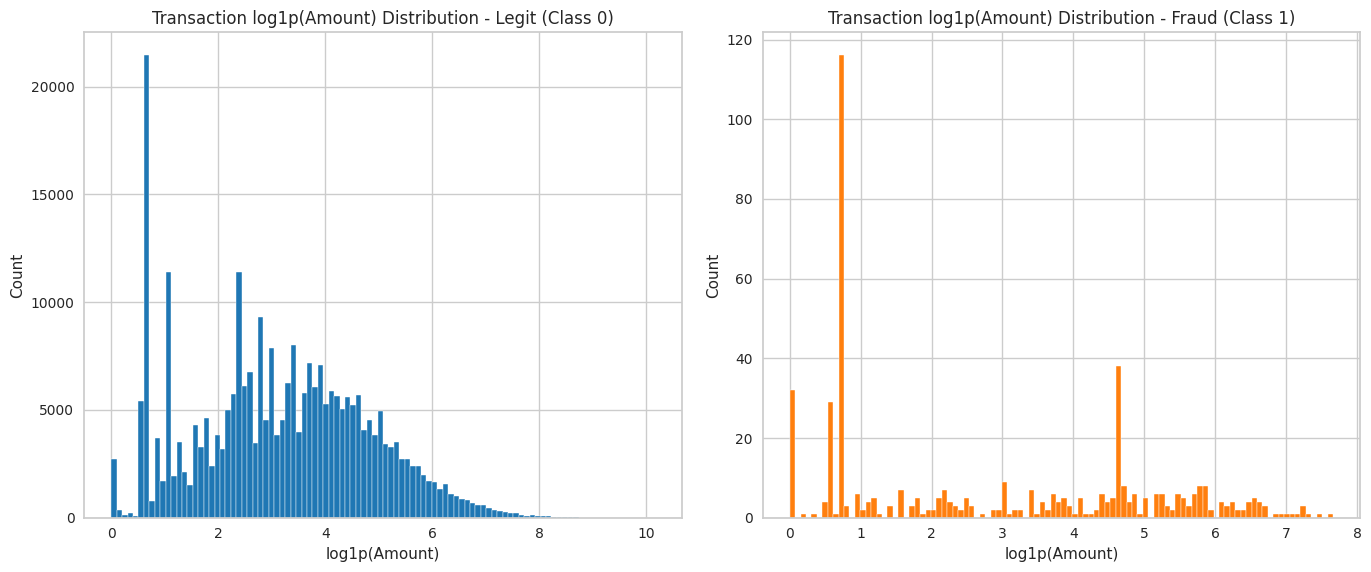

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.histplot(df[df['Class'] == 0]['LogAmount'],
             bins=100,
             stat="count",
             kde=False,
             color=sns.color_palette()[0],
             alpha=1.0,
             ax=axes[0])
axes[0].set_title("Transaction log1p(Amount) Distribution - Legit (Class 0)")
axes[0].set_xlabel("log1p(Amount)")

sns.histplot(df[df['Class']  == 1]['LogAmount'],
             bins=100,
             stat="count",
             kde=False,
             color=sns.color_palette()[1],
             alpha=1.0,
             ax=axes[1])
axes[1].set_title("Transaction log1p(Amount) Distribution - Fraud (Class 1)")
axes[1].set_xlabel("log1p(Amount)")

plt.tight_layout()
plt.savefig(FIGURES_DATA_EXPLORATION_DIR / "amount_log1p_distribution_by_class.png", dpi=300)
plt.show()

Log transformation improves interpretability:
- Brings both distributions into a more symmetric and usable form. This transformation has successfully normalized the `Amount` feature, pulling the extreme right tail back towards the center of the distribution.
- Allows better learning by models sensitive to feature scale (e.g., logistic regression, neural networks).

Raw `Amount` is not suitable for modeling In its raw form, `Amount` would cause (Use `LogAmount` instead of `Amount`):
- Scale issues
- Inefficient convergence
- Oversensitivity to outliers

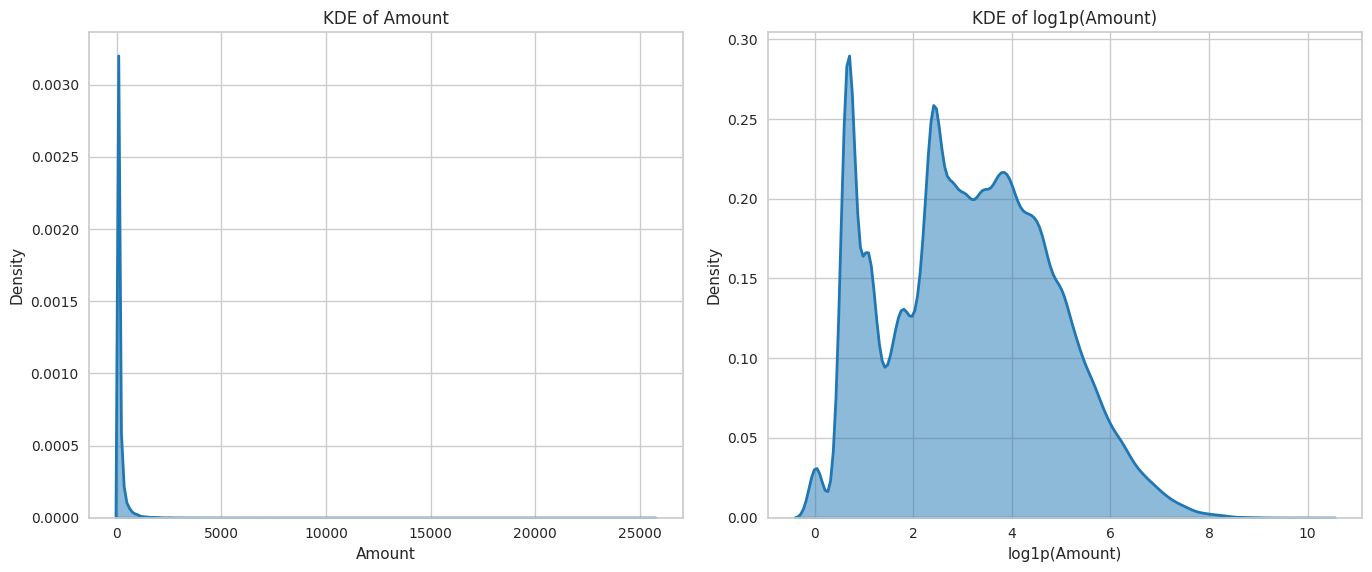

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.kdeplot(data=df,
            x="Amount",
            fill=True,
            common_norm=False,
            alpha=0.5,
            linewidth=2.0,
            ax=axes[0])
axes[0].set_title("KDE of Amount")

sns.kdeplot(data=df,
            x="LogAmount",
            fill=True,
            common_norm=False,
            alpha=0.5,
            linewidth=2.0,
            ax=axes[1])
axes[1].set_xlabel("log1p(Amount)")
axes[1].set_title("KDE of log1p(Amount)")

plt.tight_layout()
plt.savefig(FIGURES_DATA_EXPLORATION_DIR / "amount_log1p_amount_kde.png", dpi=300)
plt.show()

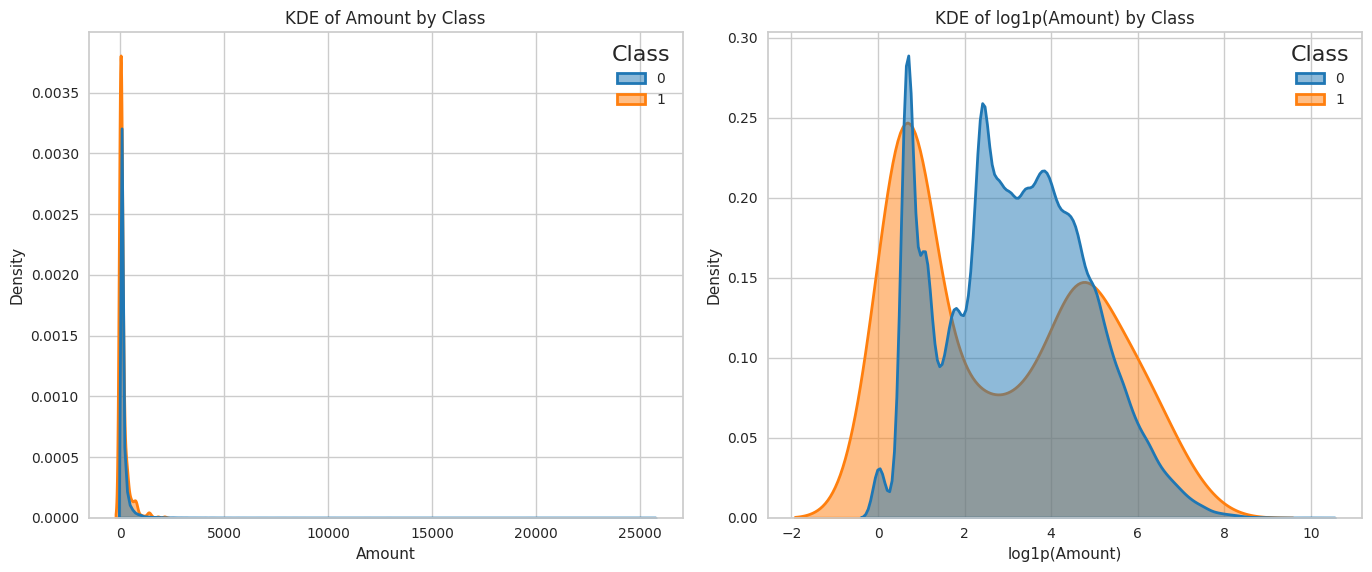

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.kdeplot(data=df,
            x="Amount",
            hue="Class",
            fill=True,
            common_norm=False,
            alpha=0.5,
            linewidth=2.0,
            ax=axes[0])
axes[0].set_title("KDE of Amount by Class")

sns.kdeplot(data=df,
            x="LogAmount",
            hue="Class",
            fill=True,
            common_norm=False,
            alpha=0.5,
            linewidth=2.0,
            ax=axes[1])
axes[1].set_xlabel("log1p(Amount)")
axes[1].set_title("KDE of log1p(Amount) by Class")

plt.tight_layout()
plt.savefig(FIGURES_DATA_EXPLORATION_DIR / "amount_log1p_amount_kde_by_class.png", dpi=300)
plt.show()

The entire density is squeezed near zero due to extreme outliers (max ~25000) for class 0, similar for class 1.

Class 1 (fraud) has a sharp peak around log ≈ 0.7 → roughly 1.00 in raw terms.

Class 0 (legit) shows a broader, multimodal spread: peaks near log ≈ 1.5–2.0 and again ≈ 4.0–5.0.

Class 1 appears concentrated, Class 0 appears diverse.

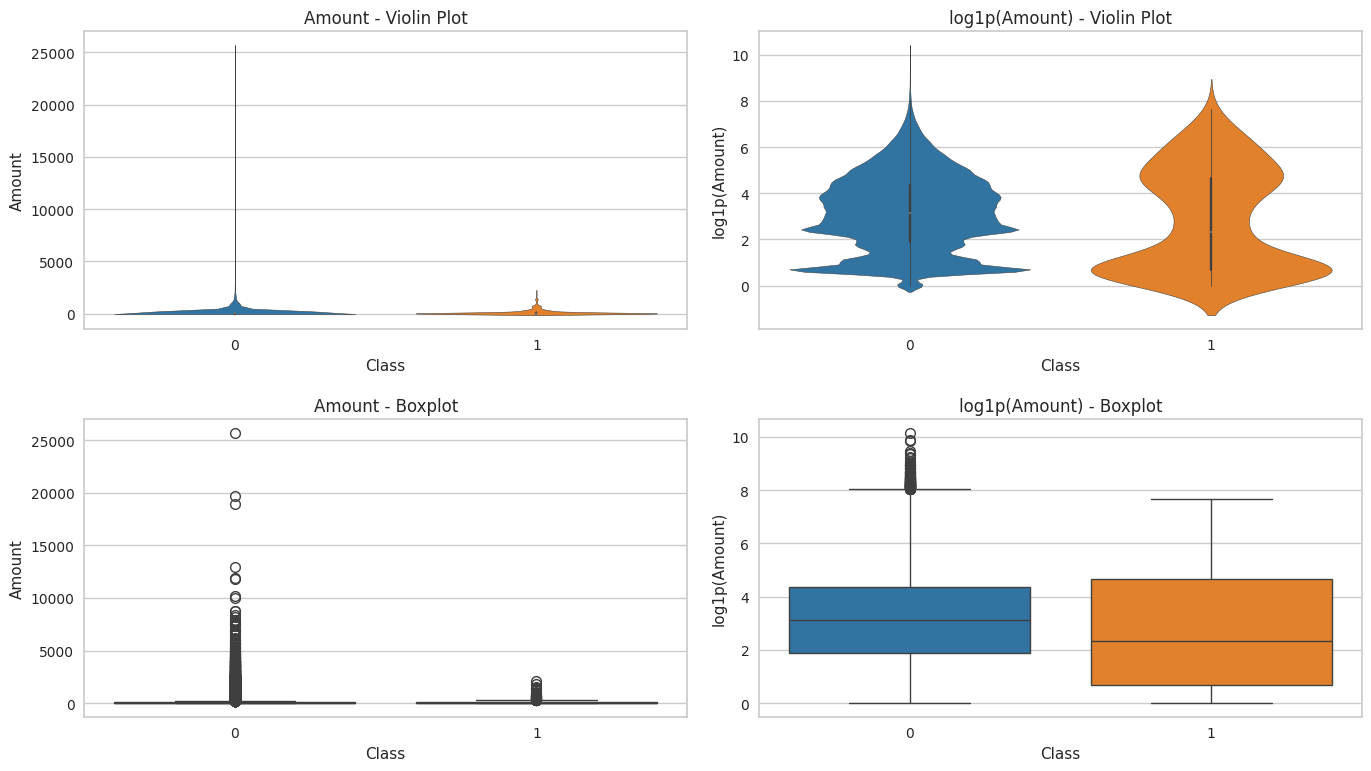

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

sns.violinplot(data=df,
               x="Class",
               y="Amount",
               hue="Class",
               ax=axes[0,0],
               legend=False)
axes[0,0].set_title("Amount - Violin Plot")

sns.violinplot(data=df,
               x="Class",
               y="LogAmount",
               hue="Class",
               ax=axes[0,1],
               legend=False)
axes[0,1].set_ylabel("log1p(Amount)")
axes[0,1].set_title("log1p(Amount) - Violin Plot")

sns.boxplot(data=df,
            x="Class",
            y="Amount",
            hue="Class",
            ax=axes[1,0],
            legend=False)
axes[1,0].set_title("Amount - Boxplot")

sns.boxplot(data=df,
            x="Class",
            y="LogAmount",
            hue="Class",
            ax=axes[1,1],
            legend=False)
axes[1,1].set_ylabel("log1p(Amount)")
axes[1,1].set_title("log1p(Amount) - Boxplot")

plt.tight_layout()
plt.savefig(FIGURES_DATA_EXPLORATION_DIR / "amount_log1p_amount_box_violin_by_class.png", dpi=300)
plt.show()

We can confirm that class 0 has extreme outliers up to 25000, while mostly data are tightly packed below 500. For class 1, we have a much tighter range, nearly all under 2000.

Boxplot shows massive skew and outlier influence in class 0. In general, amount is dominated by extreme values, especially in class 0.

 Log transform stabilizes variance, compresses outliers, and makes fraud/legit distributions visually and statistically manageable.

##  PCA Feature Analysis (V1-V28)

### Summary statistics + KDE plots of PCs + Correlation Matrix

In [36]:
pcs_cols_name = [f"V{i}" for i in range(1, 29)]
df[pcs_cols_name].describe().T

,count,mean,std,min,25%,50%,75%,max
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995
V10,284807.0,2.239053e-15,1.088850,-24.588262,-0.535426,-0.092917,0.453923,23.745136


In [37]:
df[pcs_cols_name].skew()

V1     -3.280667
V2     -4.624866
V3     -2.240155
V4      0.676292
V5     -2.425901
V6      1.826581
V7      2.553907
V8     -8.521944
V9      0.554680
V10     1.187141
V11     0.356506
V12    -2.278401
V13     0.065233
V14    -1.995176
V15    -0.308423
V16    -1.100966
V17    -3.844914
V18    -0.259880
V19     0.109192
V20    -2.037155
V21     3.592991
V22    -0.213258
V23    -5.875140
V24    -0.552499
V25    -0.415793
V26     0.576693
V27    -1.170209
V28    11.192091
dtype: float64

1. **mean**: All components have a mean very close to 0 (between -0.009 and 0.002), suggesting that the data was centered before PCA — this is consistent with a correctly applied PCA.
2. **std**:
    - High for PC1 – PC6 (> 1.3)
    - Medium for PC7 – PC13 (1.0 – 1.3)
    - Low for PC14 – PC28 (< 1.0)

The first six components likely explain most of the variance (e.g., PC1 std ≈ 1.95). The variance decreases monotonically, as expected from PCA. The last components (PC25–PC28) have very low standard deviation (e.g., PC28: std ≈ 0.328), and could potentially be dropped in predictive modeling.

3. **min, max**:
    - Some components have extreme values, hinting at possible outliers. Examples:
        - PC5: min ≈ -113, max ≈ 34
        - PC7: max ≈ 120

    - Others (like PC20–PC28) have much tighter ranges

4. **Median and Quartiles (50%, 25%, 75%)**
- The median is always close to 0.
- Quartiles are typically symmetrically distributed around zero, consistent with centered distributions.
- However, some components (e.g., PC5, PC6, PC7) show extreme values far from the quartiles → possible unilateral outliers.

---

**PCA seems correctly applied**:
- Data is centered (mean ≈ 0).
- The first components carry most of the variance → informative.
- The last components (PC20–PC28) could be safely removed with minimal information loss.

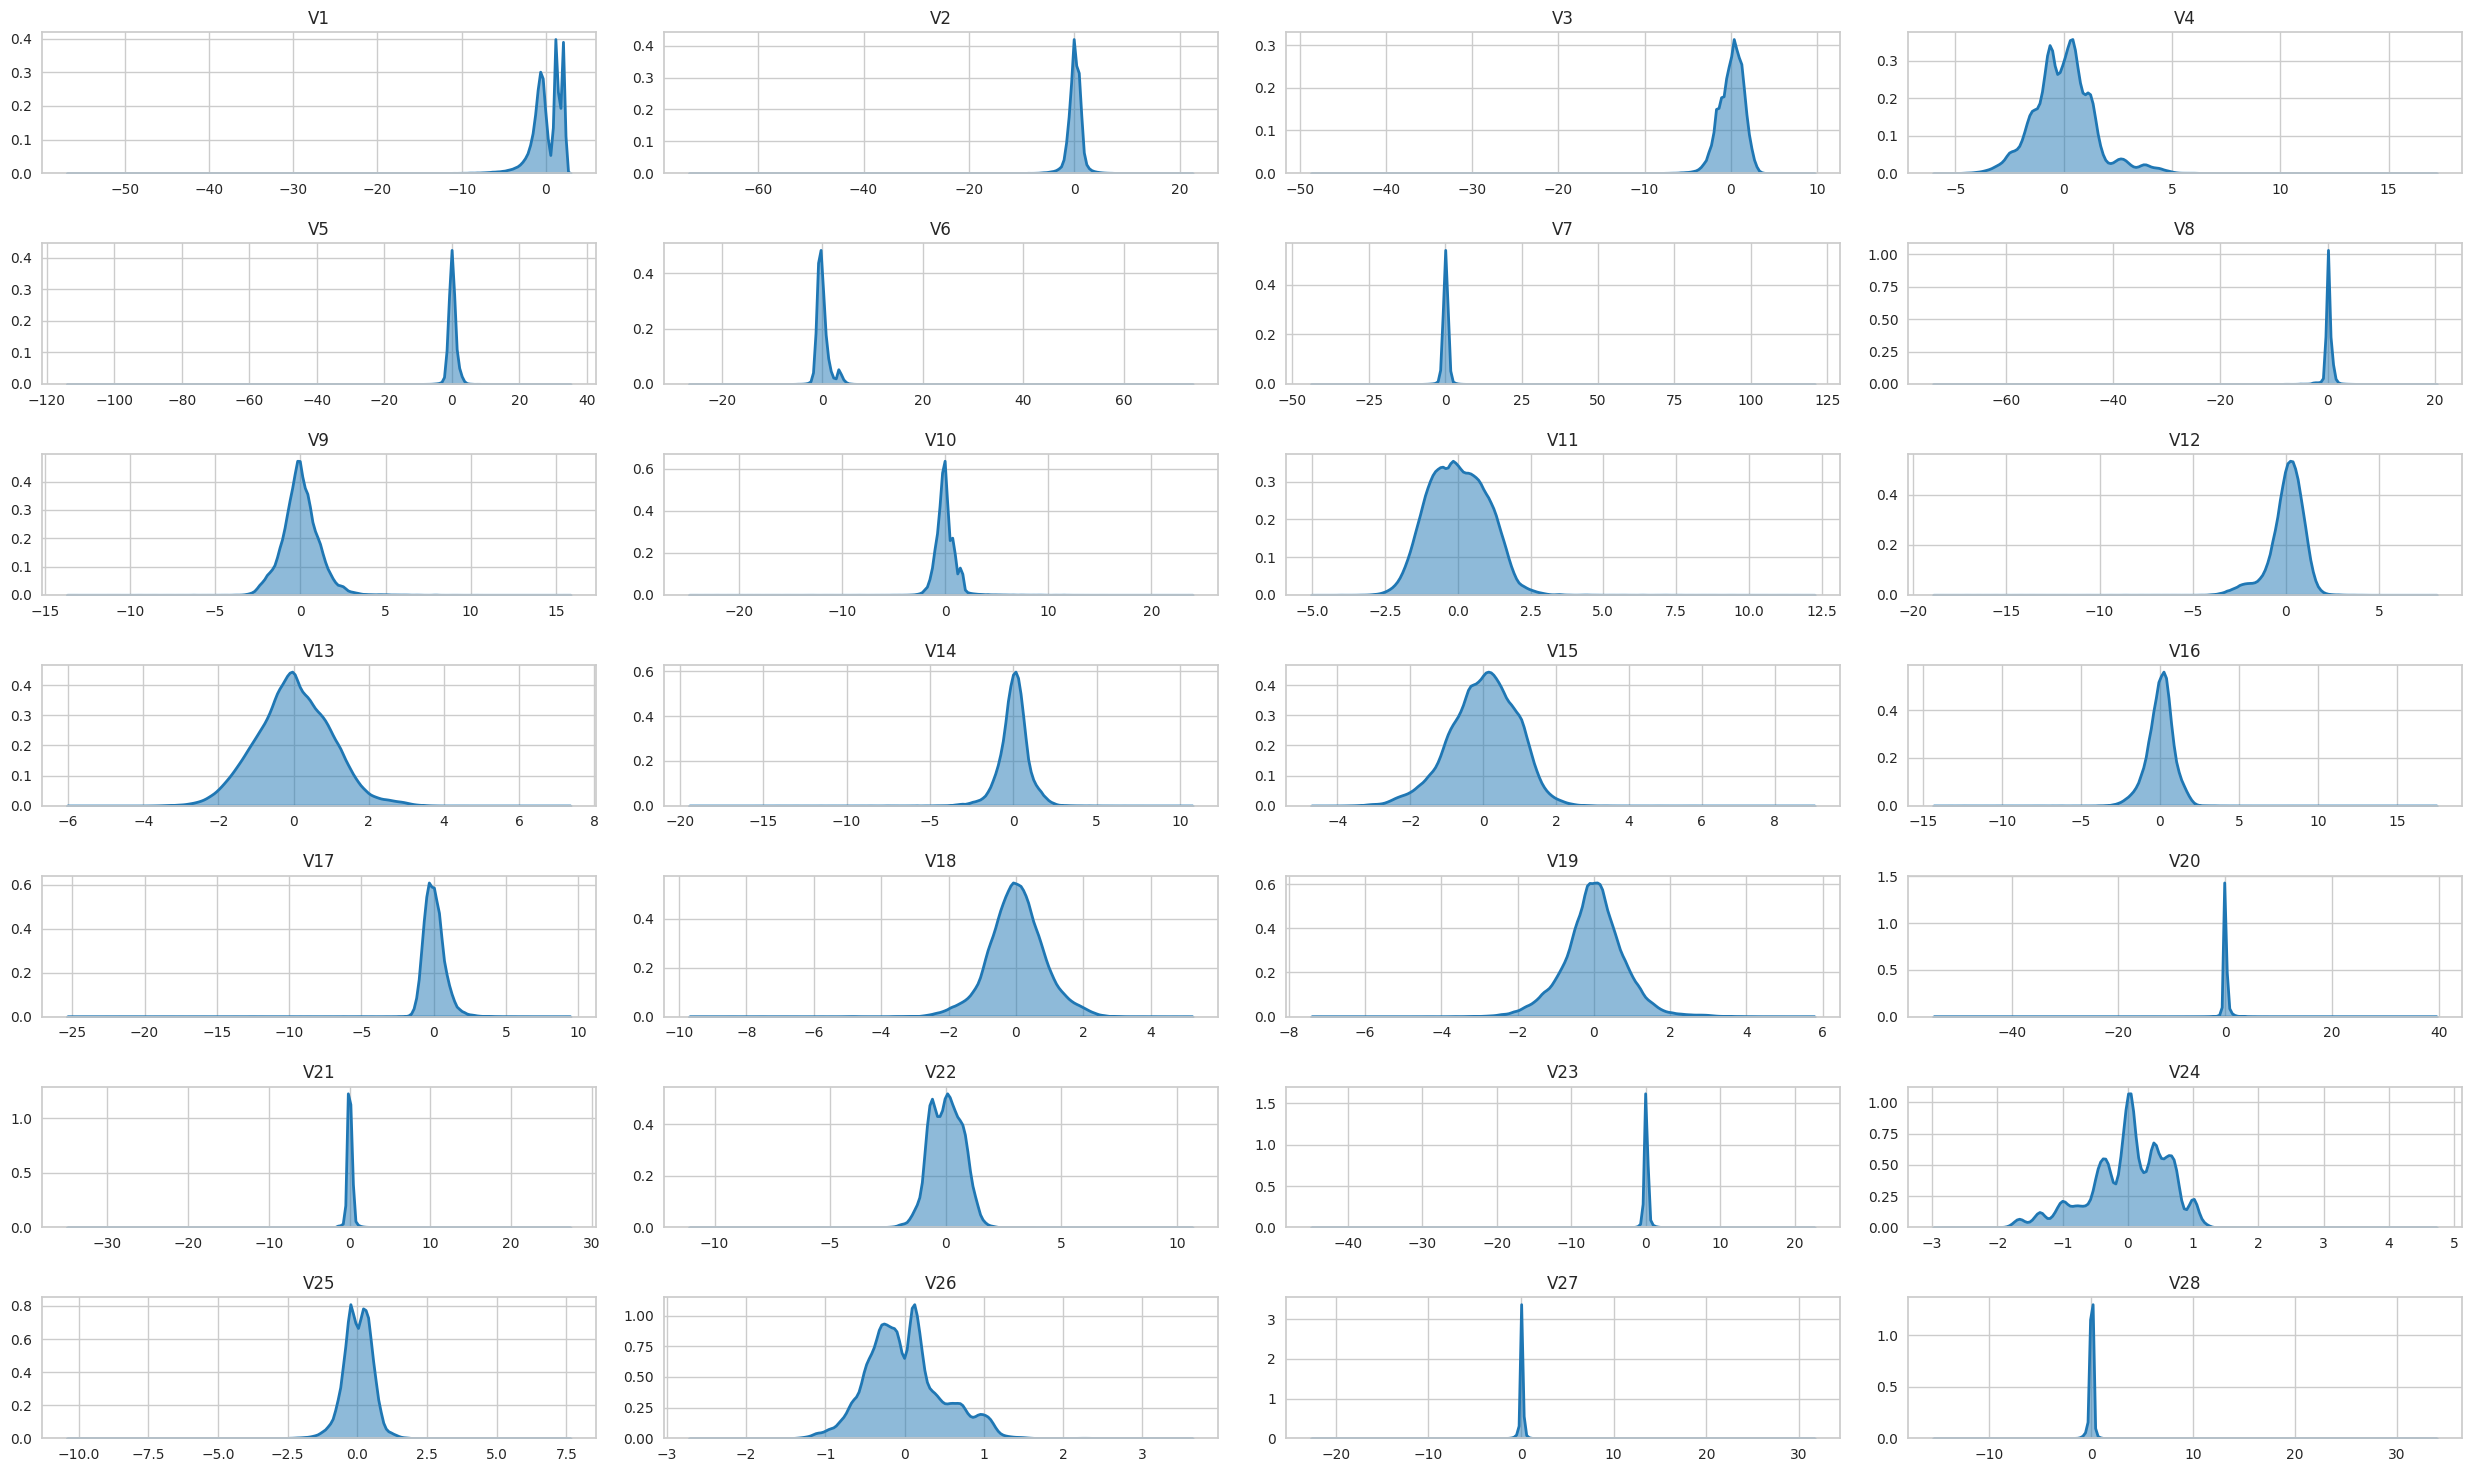

In [38]:
fig, axes = plt.subplots(7, 4, figsize=(25, 15))
axes = axes.flatten()

for i, col in enumerate(pcs_cols_name):
    sns.kdeplot(data=df,
                x=col,
                fill=True,
                common_norm=False,
                alpha=0.5,
                linewidth=2.0,
                ax=axes[i])

    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

for j in range(len(pcs_cols_name), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig(FIGURES_DATA_EXPLORATION_DIR / "pcs_kde.png", dpi=300)
plt.show()

Most components are centered around 0, with bell-like or symmetric shapes — consistent with centered data.

Some PCs show:

- Multimodal behavior (e.g., V1, V4, V24, V26) → this is not an error; it may indicate structured variance.

- Long tails or high peaks (e.g., V5, V7, V28) → indicates variance concentration and possibly outliers, which is expected in PCA.

The PCA space appears centered, and the projections are consistent with real structured data. No sign of errors.

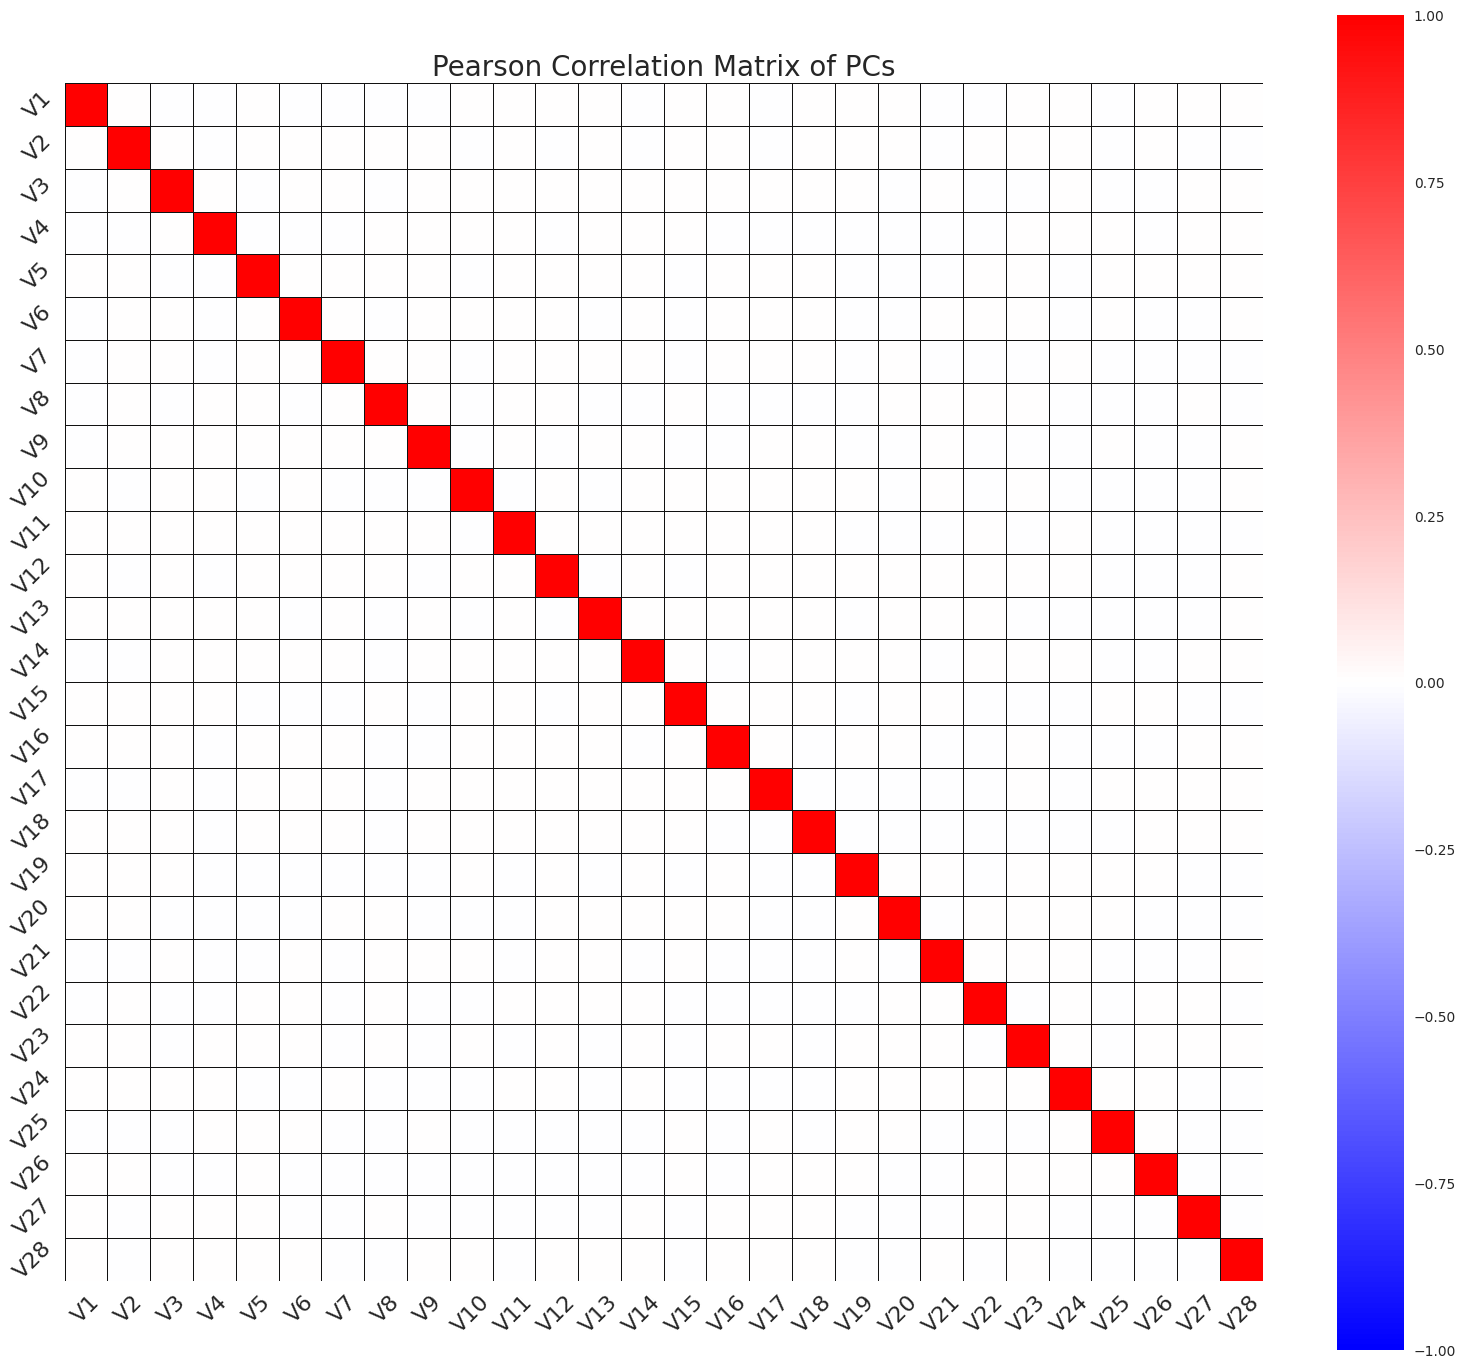

In [39]:
corr = df[pcs_cols_name].corr()

plt.figure(figsize=(16, 14))
sns.heatmap(
    corr,
    cmap="bwr",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    annot=False,
    linecolor="k",
    linewidths=0.5,
)

plt.tick_params(labelsize=16)
plt.title("Pearson Correlation Matrix of PCs", fontsize=20)
plt.tick_params(labelsize=16, rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DATA_EXPLORATION_DIR / "pcs_correlation_matrix.png", dpi=300)
plt.show()

The heatmap shows no off-diagonal structure.

All off-diagonal elements are white (correlation ≈ 0), and only the diagonal is red (corr = 1).

The components are uncorrelated — this is the key mathematical property of PCA (orthogonal projection).

### Cumulative Explained Variance

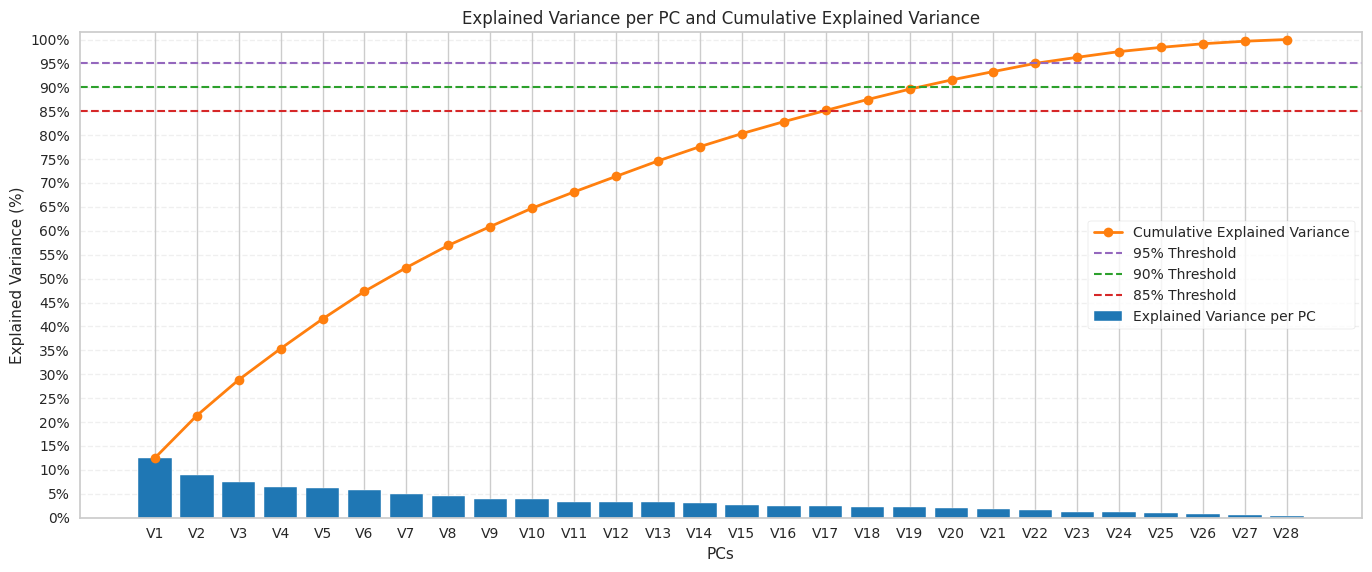

In [40]:
df_pcs = df[pcs_cols_name]
var_ratio = df_pcs.var(axis=0)
var_ratio = var_ratio / var_ratio.sum()
cumulative = var_ratio.cumsum()

# show single variance and cumulative variance in %
single_pct = (var_ratio * 100)
cumulative_pct = (cumulative * 100)
pcs = df_pcs.columns

fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(pcs, single_pct, label='Explained Variance per PC', color="#1f77b4")
ax.plot(pcs, cumulative_pct, marker="o", label="Cumulative Explained Variance",
        linewidth=2, color="#ff7f0e" )

ax.axhline(95, linestyle='--', linewidth=1.5, color="#9467bd" ,
           label=f'95% Threshold')
ax.axhline(90, linestyle='--', linewidth=1.5, color="#2ca02c" ,
           label=f'90% Threshold')
ax.axhline(85, linestyle='--', linewidth=1.5, color="#d62728" ,
           label=f'85% Threshold')

ax.set_yticks(np.arange(0, 110, 5))
ax.set_ylabel('Explained Variance (%)')
ax.set_xlabel('PCs')
ax.set_title('Explained Variance per PC and Cumulative Explained Variance')

ax.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
ax.set_ylim(0, 101.5)

ax.legend(loc='center right', frameon=True)

plt.grid(True, axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DATA_EXPLORATION_DIR / "pcs_cum_estimated_variance.png", dpi=300)
plt.show()

### KDE plots of PCs stratified by class

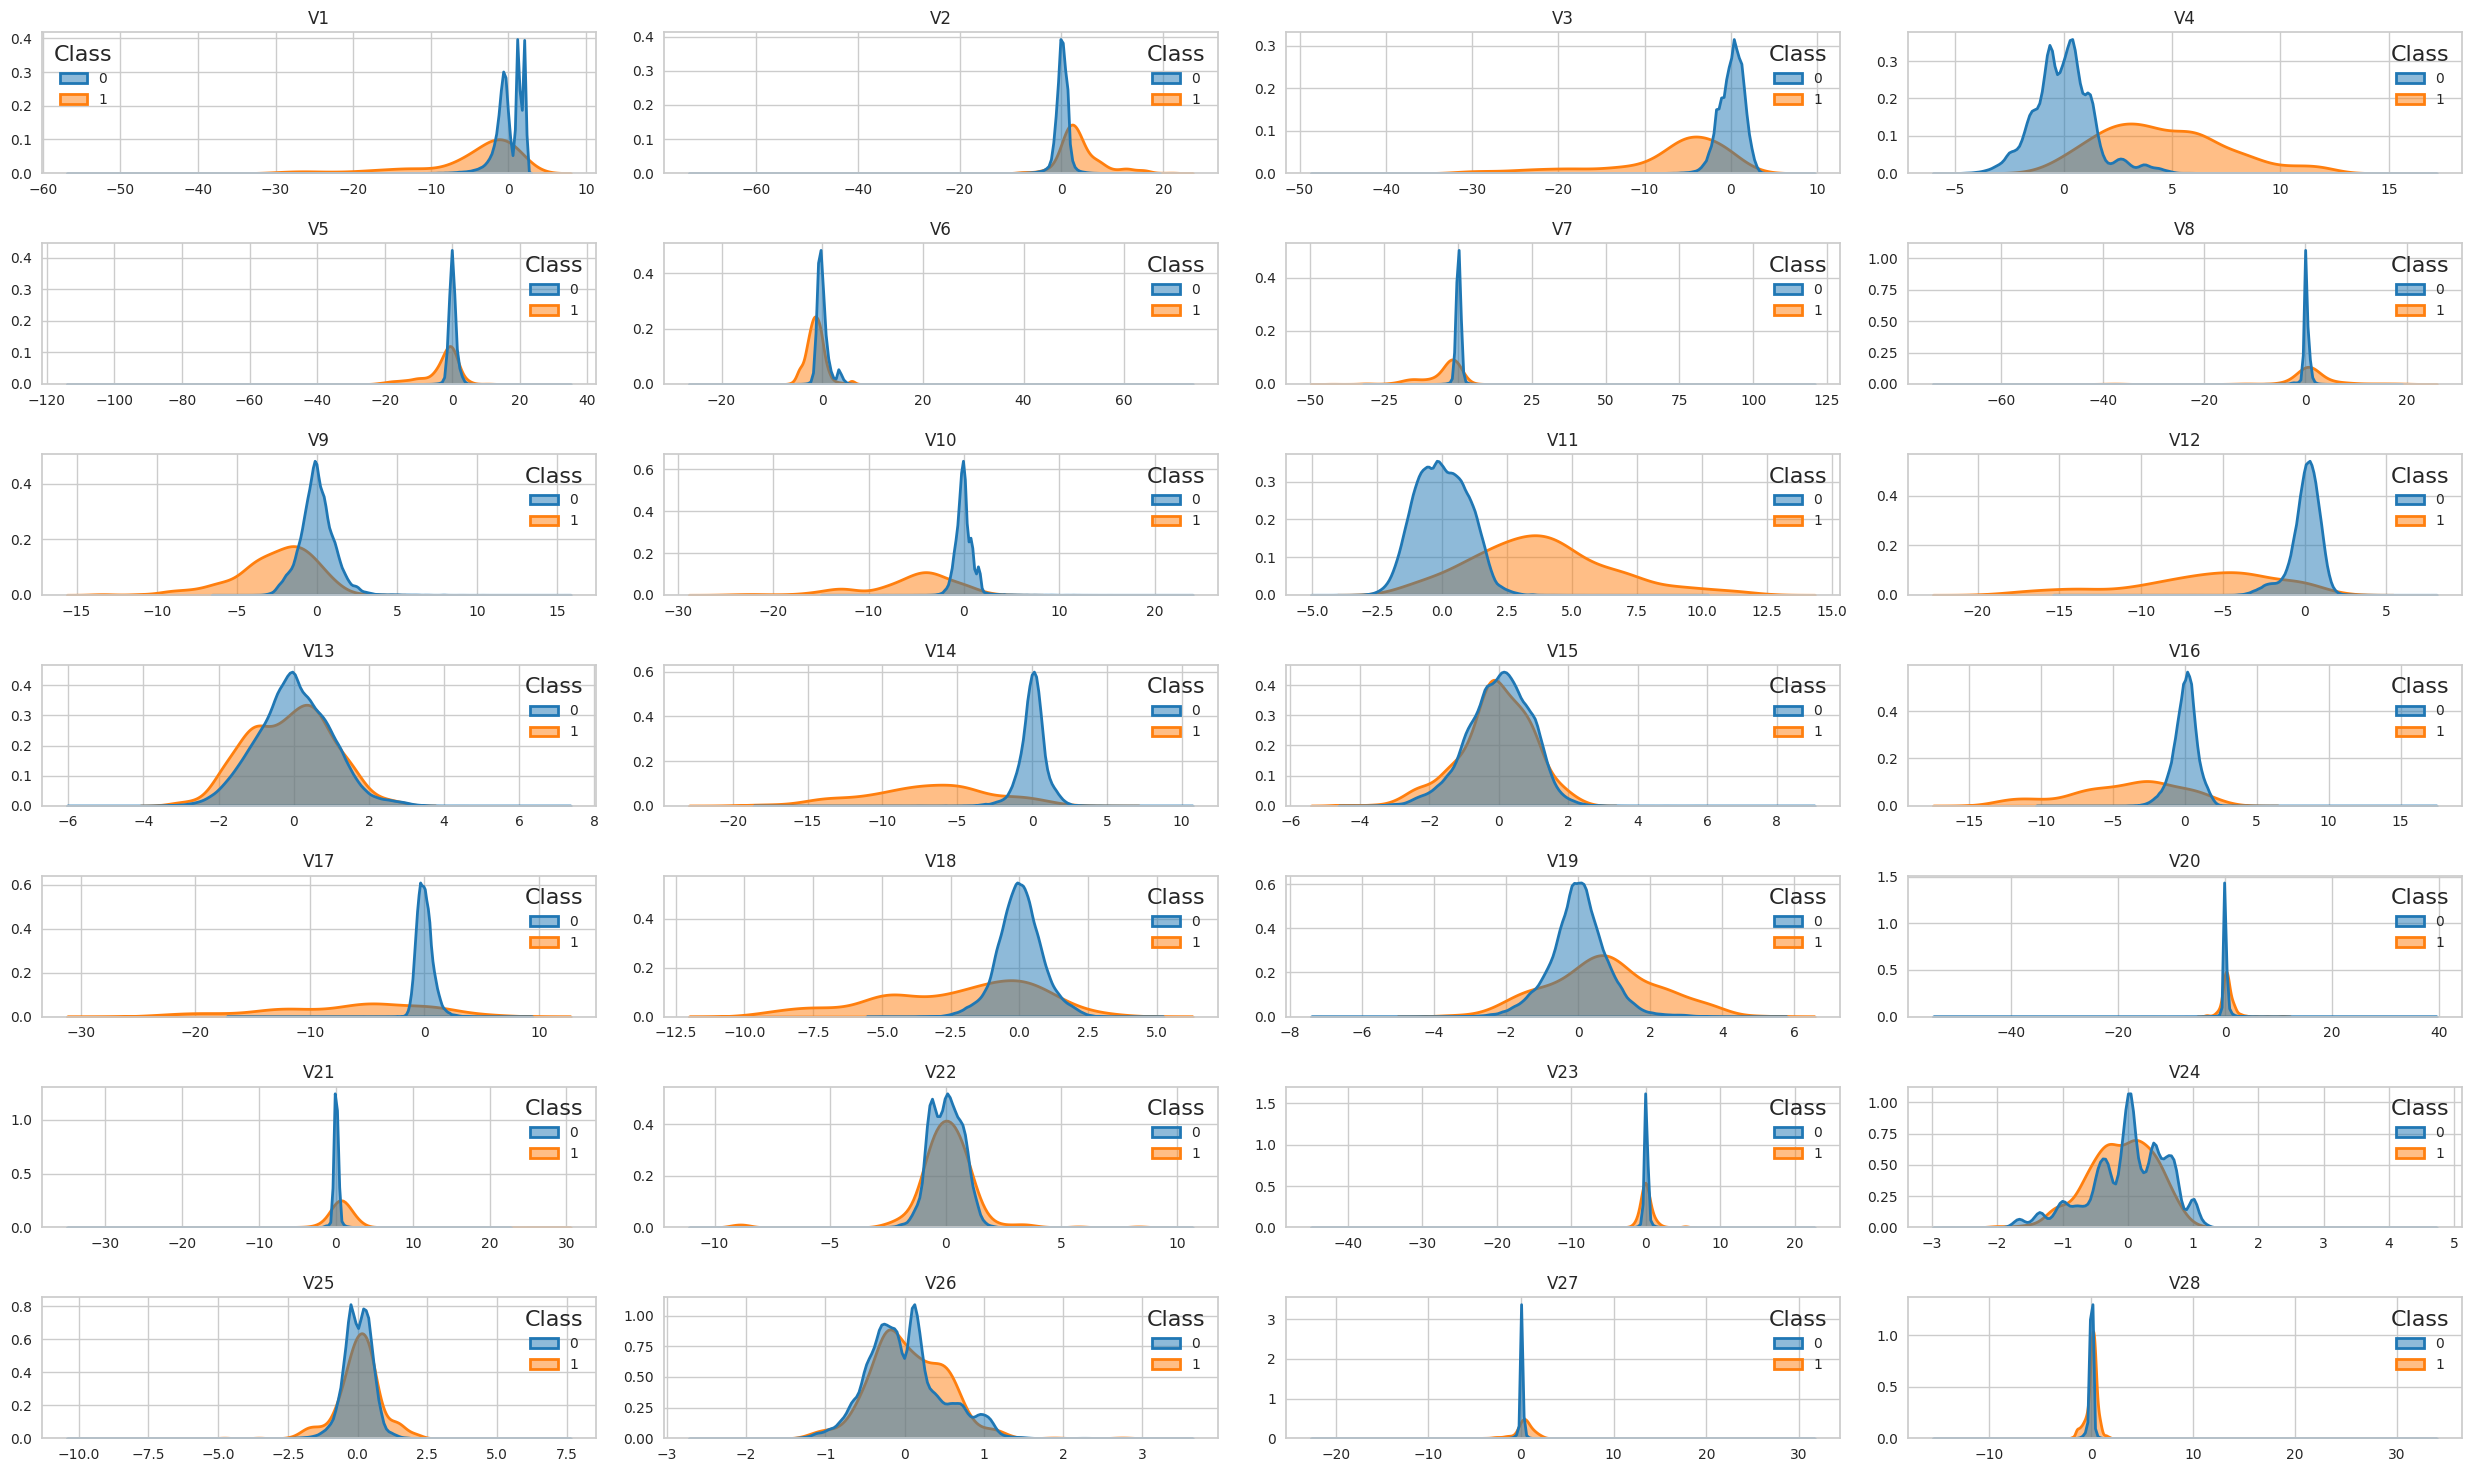

In [41]:
fig, axes = plt.subplots(7, 4, figsize=(25, 15))
axes = axes.flatten()

for i, col in enumerate(pcs_cols_name):
    sns.kdeplot(data=df,
                x=col,
                hue="Class",
                fill=True,
                common_norm=False,
                alpha=0.5,
                linewidth=2.0,
                ax=axes[i])

    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

for j in range(len(pcs_cols_name), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig(FIGURES_DATA_EXPLORATION_DIR / "pcs_kde_by_class.png", dpi=300)
plt.show()

Some insights that should be better investigated:
- V4, V10, V11, V12, V14, V17 are highly promising candidates for model discrimination and maybe feature selection.
- V2, V3, V5, V6, V8, V13, V16, V18, V22 may not separate well alone but could help in interaction with others.
- V1, V7, V9, V19, V20, V21, V23, V28, V15, V26 are probably noise or redundant for classification.

## Overall Feature Structure and Redundancy

### Pearson Correlation Heatmap among Features

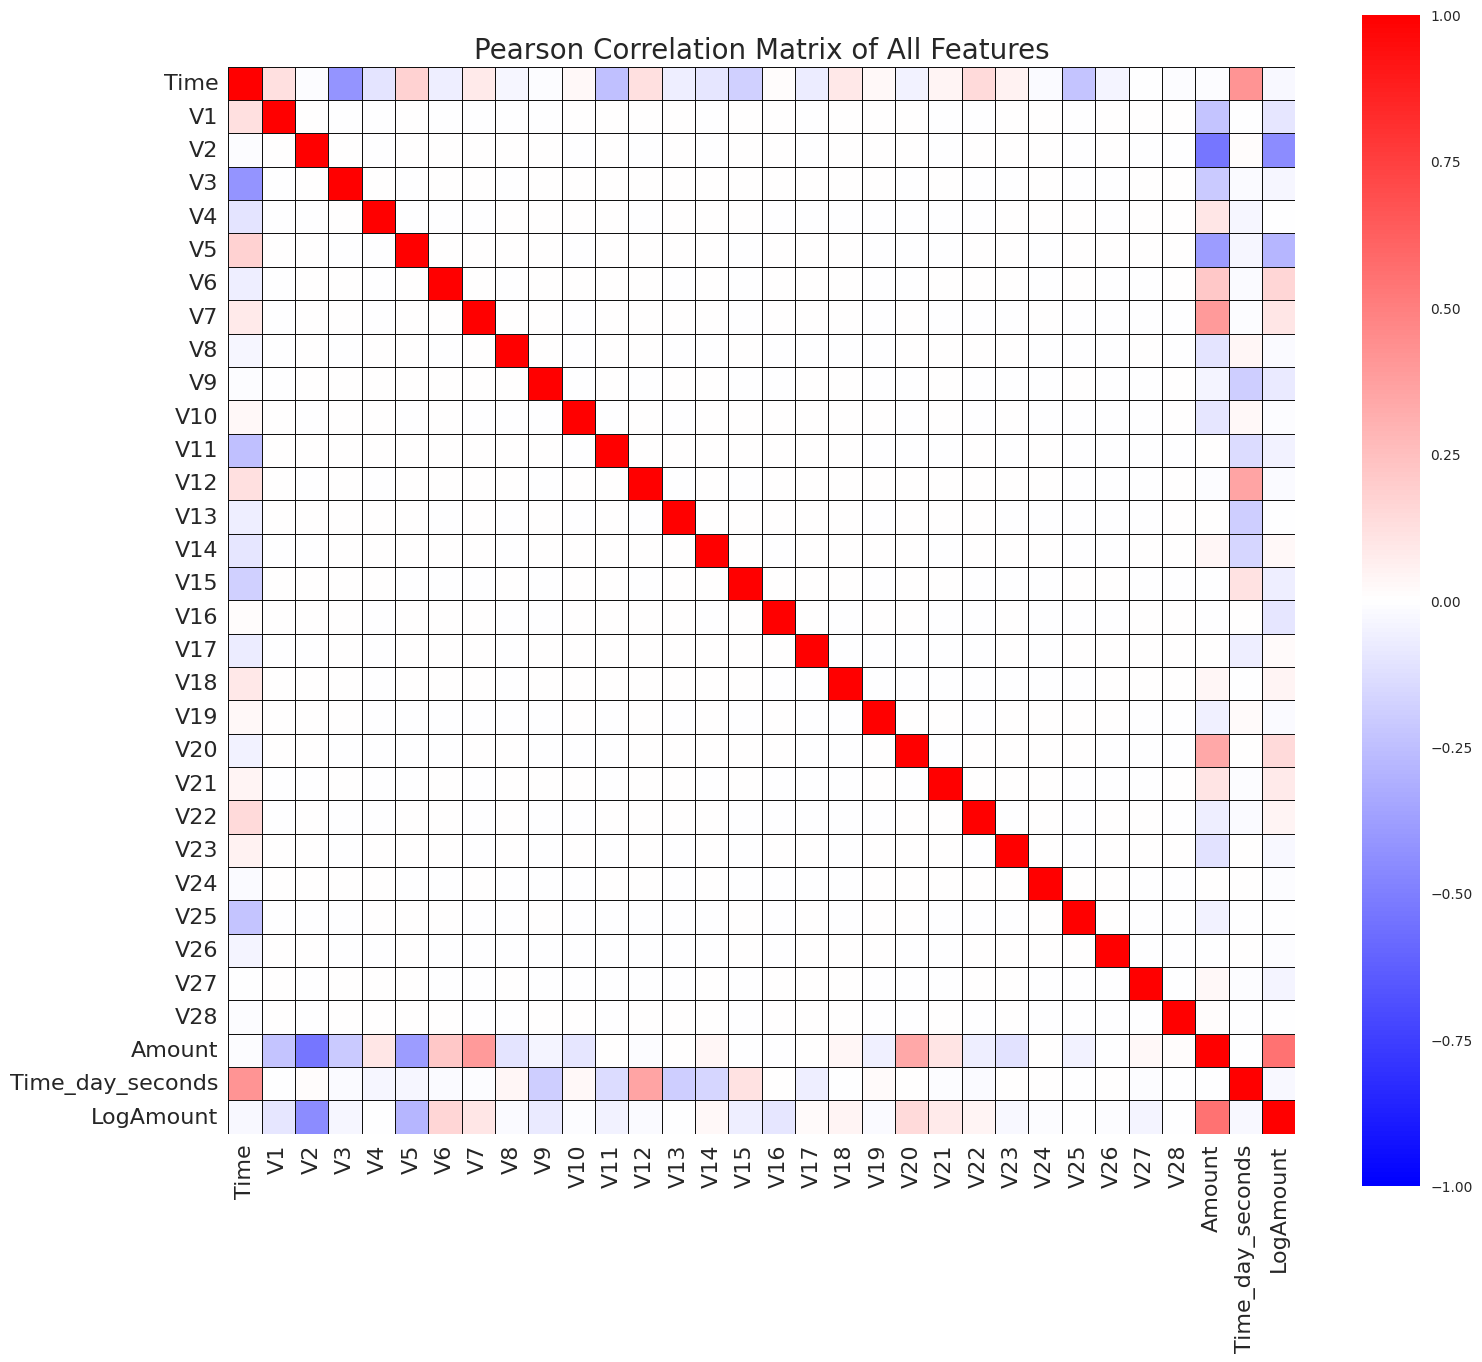

In [42]:
# Compute the correlation matrix (excluding the 'Class' column)
corr = df.loc[:, df.columns != 'Class'].corr()

plt.figure(figsize=(16, 14))
sns.heatmap(
    corr,
    cmap="bwr",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    annot=False,
    linecolor="k",
    linewidths=0.5,
)

plt.tick_params(labelsize=16)
plt.title("Pearson Correlation Matrix of All Features", fontsize=20)
plt.tight_layout()
plt.savefig(FIGURES_DATA_EXPLORATION_DIR / "all_features_correlation_matrix.png", dpi=300)
plt.show()

The PCA components (V1–V28) are mostly uncorrelated, confirming that:
- PCA transformation was applied correctly
- Features are orthogonal (linearly independent) → No need to remove features due to collinearity

A few weak-to-moderate correlations are visible among:

- LogAmount and V12–V14

- Time and early PCA components (e.g., V1, V4)

### Shapiro Ranking (Normality Check per Feature)

/home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Dynamic-Ensemble-Learning-for-Credit-Card-Fraud-Detection/venv/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 284807.
  res = hypotest_fun_out(*samples, **kwds)


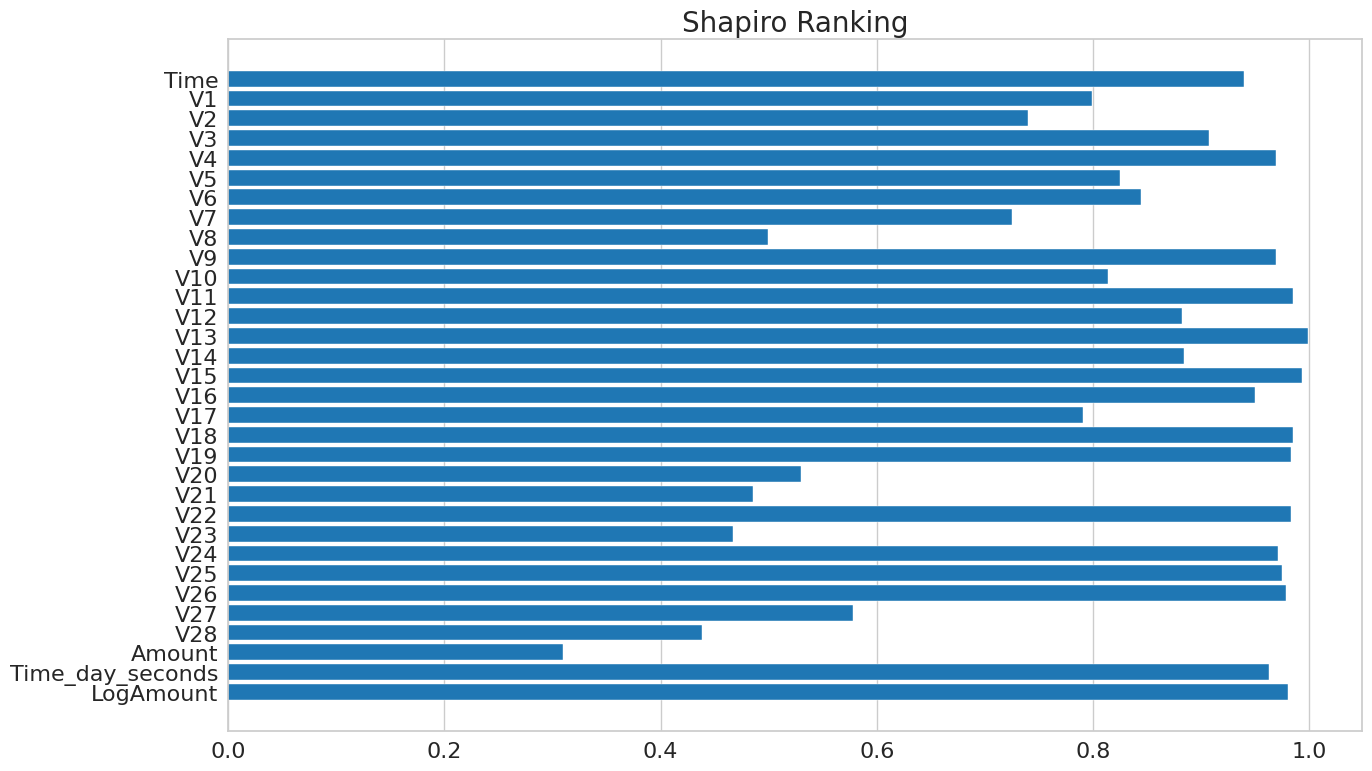

In [43]:
# Instantiate the 1D visualizer with the Shapiro ranking algorithm
X = df.loc[:, df.columns != 'Class']
y = df["Class"]
visualizer = Rank1D(algorithm='shapiro')

plt.figure(figsize=(14, 8))
visualizer.fit(X, y)           # Fit the data to the visualizer
visualizer.transform(X)        # Transform the data

plt.title("Shapiro Ranking", fontsize=20)
plt.tick_params(labelsize=16)
plt.tight_layout()
plt.savefig(FIGURES_DATA_EXPLORATION_DIR / "all_features_shapiro_rank.png", dpi=300)
plt.show()

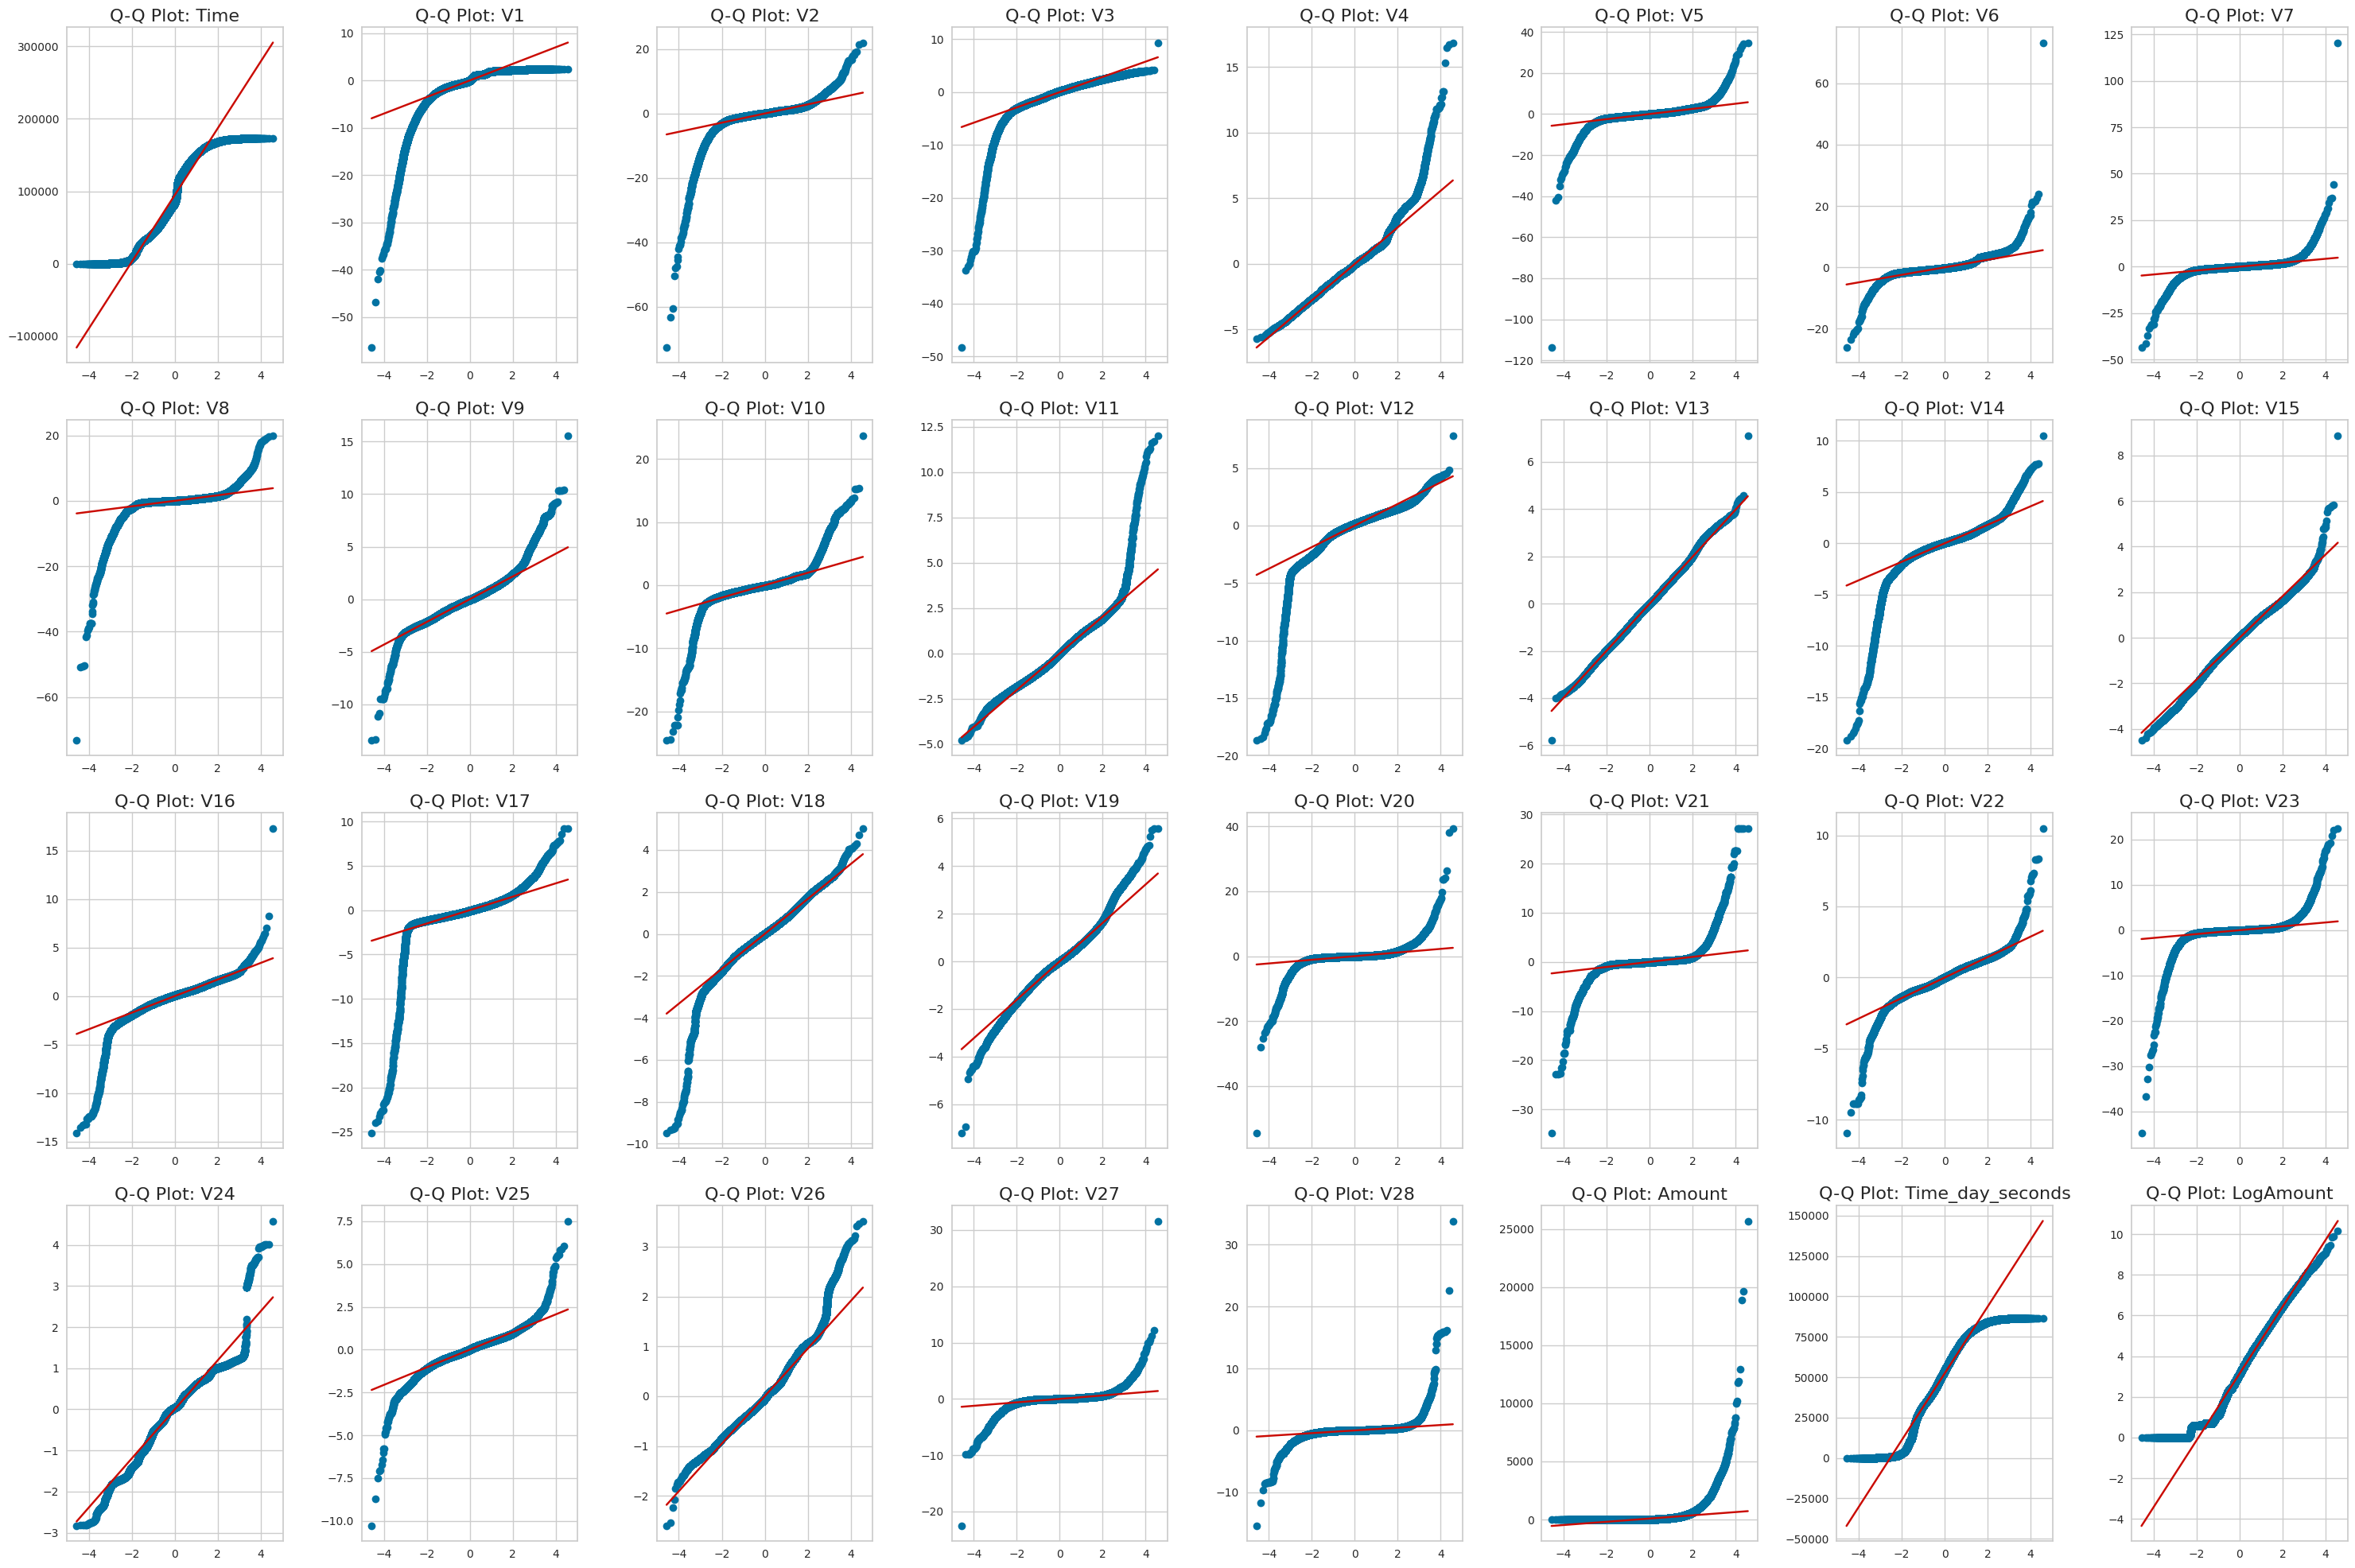

In [44]:
features = [col for col in df.columns if col != "Class"]

n_cols = 8
n_rows = (len(features) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(30, 5 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(features):
    stats.probplot(df[feature], dist="norm", plot=axes[i])
    axes[i].set_title(f"Q-Q Plot: {feature}", fontsize=16)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig(FIGURES_DATA_EXPLORATION_DIR / "all_features_qq_plot.png", dpi=300)
plt.show()

## Features Relevance to Target class

### Features Correlation with Target

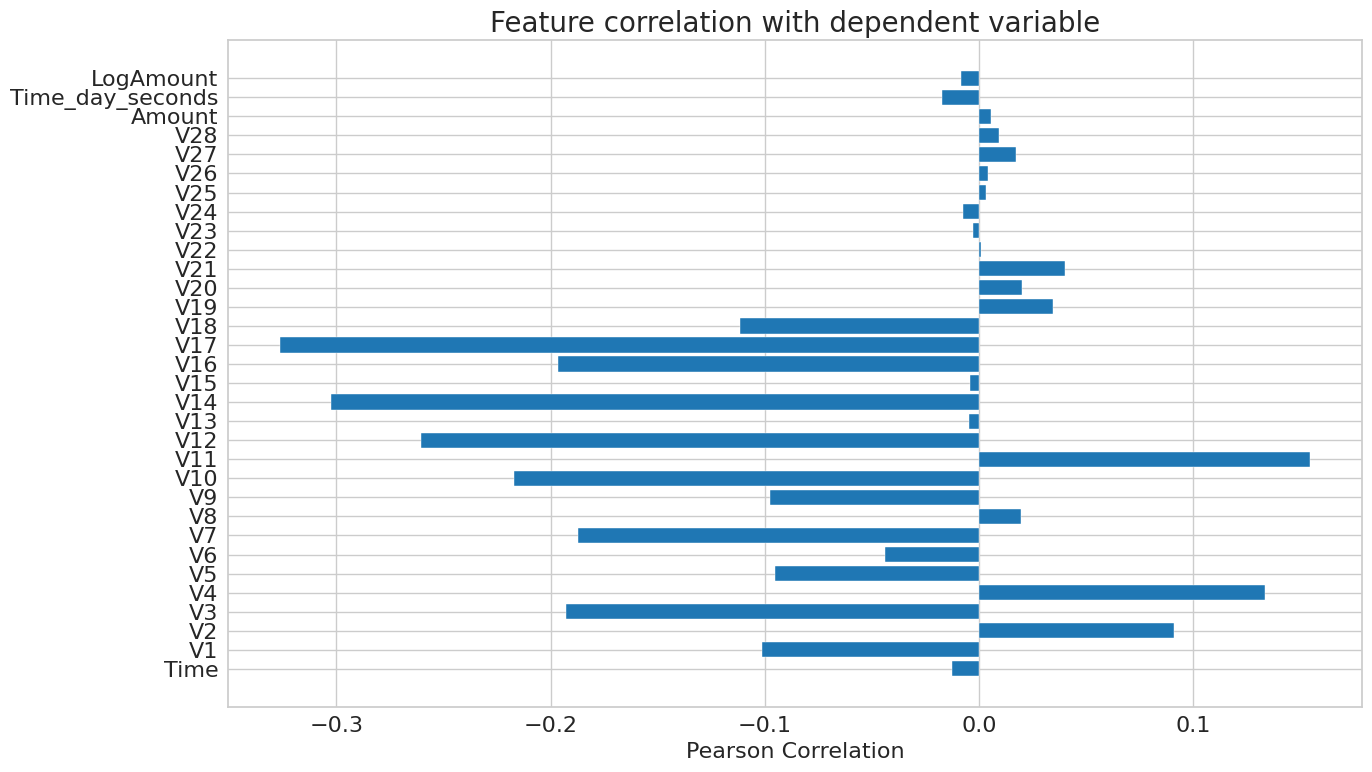

In [45]:
X = df.loc[:, df.columns != 'Class']
y = df["Class"]

plt.figure(figsize=(14, 8))
viz = FeatureCorrelation(labels=X.columns, method="pearson")
viz.fit(X, y)

plt.title("Feature correlation with dependent variable", fontsize=20)
plt.xlabel("Pearson Correlation", fontsize=16)
plt.tick_params(labelsize=16)
plt.tight_layout()
plt.savefig(FIGURES_DATA_EXPLORATION_DIR / "all_features_correlation_with_class.png", dpi=300)
plt.show()

PCA features V11–V17 carry strong linear separability.
- V11, V12, V14, V17, V10	Strongest (negative) correlation with fraud class
- LogAmount, Hour, Time	Weak or no linear correlation
- Amount close to 0 correlation

### Mutual Information with Target

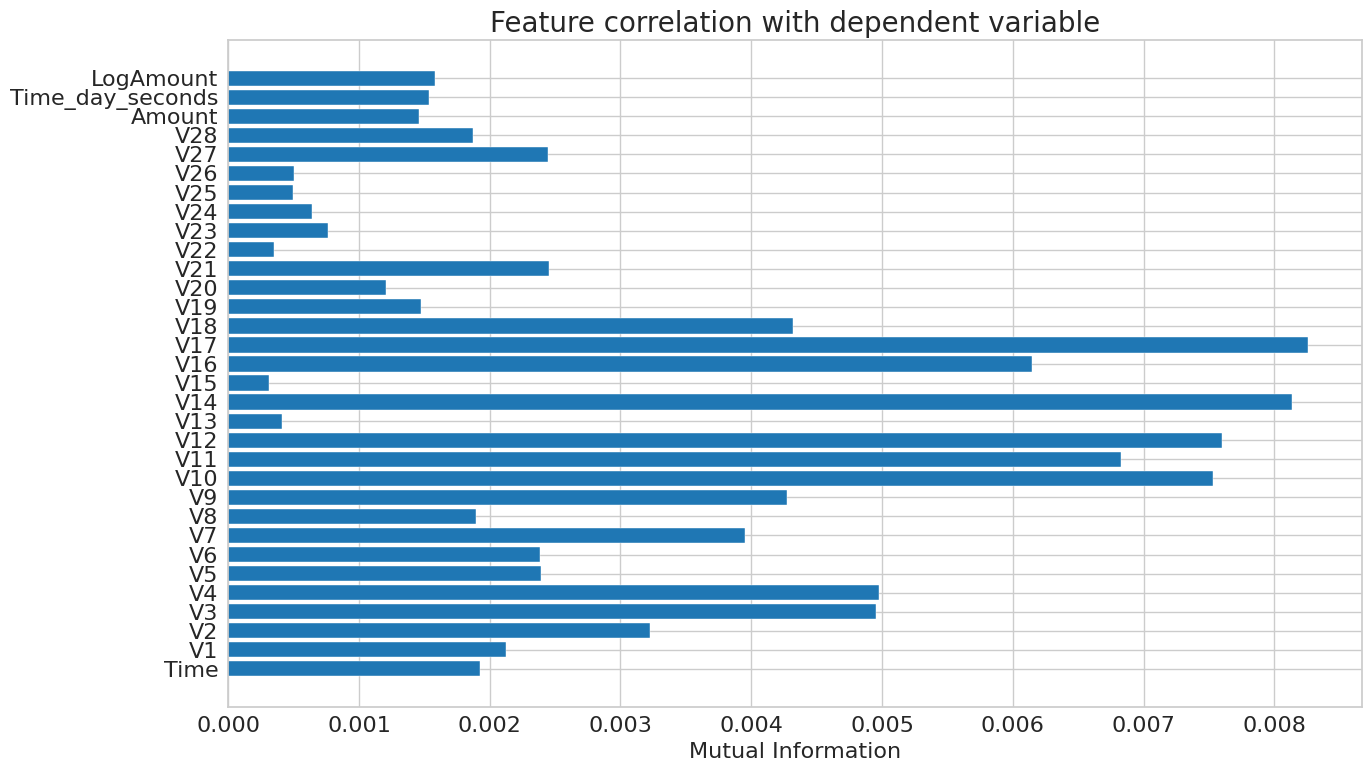

In [46]:
X = df.loc[:, df.columns != 'Class']
y = df["Class"]

plt.figure(figsize=(14, 8))
viz = FeatureCorrelation(labels=X.columns, method="mutual_info-classification")
viz.fit(X, y)

plt.title("Feature correlation with dependent variable", fontsize=20)
plt.xlabel("Mutual Information", fontsize=16)
plt.tick_params(labelsize=16)
plt.tight_layout()
plt.savefig(FIGURES_DATA_EXPLORATION_DIR / "all_features_mutual_information_with_class.png",
            dpi=300)
plt.show()

No feature has extremely high MI (> 0.01), which is expected due to high class imbalance and feature obfuscation (PCA):
- V17, V14, V12, V11, V10, V27	Highest MI — top fraud indicators
- LogAmount, Hour — Moderate MI (more relevant than many PCA features)
- Amount (raw) — Less informative than LogAmount
- Many PCA features (e.g., V1, V4, V3, V8) — Carry small but non-zero signal